# Stability prediction (mega-scale)

## 1. Setup & imports

In [ ]:
import os
import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import (
    spearmanr, kendalltau, wilcoxon, mannwhitneyu,
    friedmanchisquare, shapiro, normaltest,
)
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None, 'display.max_columns', None)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Helper functions

In [ ]:
def has_synonymous_mutation(mutant_str: str) -> bool:
    """Check if any single-point mutation is synonymous (e.g. A12A)."""
    matches = re.findall(r'([A-Z])\d+([A-Z])', mutant_str)
    return any(orig == new for orig, new in matches)


def compute_pred_score(pred_dict: dict, mutant_str: str):
    """
    Look up predictor score for a mutant string.
    For multi-mutants (e.g. 'T39P:T46I'), sum individual scores.
    Returns None if any component mutation is missing from pred_dict.
    """
    if ':' in mutant_str:
        parts = mutant_str.split(':')
        if any(m not in pred_dict for m in parts):
            return None
        return sum(pred_dict[m] for m in parts)
    return pred_dict.get(mutant_str, None)


def parse_ddg_column(series: pd.Series) -> pd.Series:
    """Vectorized conversion of ddG_ML column (handles '-' as NaN)."""
    return pd.to_numeric(series.replace('-', float('nan')), errors='coerce')


def filter_synonymous(df: pd.DataFrame, mutant_col: str = 'mutant') -> pd.DataFrame:
    """Remove rows where the mutation is synonymous."""
    mask = ~df[mutant_col].apply(has_synonymous_mutation)
    return df[mask].reset_index(drop=True)


def extract_characters(value):
    """Extract first/last characters from mutation strings like 'A12B' or 'T39P:T46I'."""
    if ':' in value:
        part1, part2 = value.split(':')
        return part1[0], part1[-1], part2[0], part2[-1]
    return value[0], value[-1], None, None


def Average(lst):
    return sum(lst) / len(lst) if lst else 0.0

## 3. Paths
Update these to match your Google Drive layout.

In [ ]:
mega_scale_path = '/content/drive/MyDrive/Colab Notebooks/4thYear/mega_scale_stability/'
mCSM_path       = '/content/drive/MyDrive/Colab Notebooks/5thYear/mCSMmega_scale_outputs/'
MSA_Transformer_ESM_path = mega_scale_path + 'mega_scale_MSA_Transformer_ESM_outputs/'
D2D_features_dir = '/content/drive/MyDrive/Colab Notebooks/5thYear/D2D_features_megascale_revamp/D2D_features_unmutated'

D2D_features_files = [f for f in os.listdir(D2D_features_dir) if f.endswith('.csv')]
print(f'Found {len(D2D_features_files)} D2D feature files')

Found 166 D2D feature files


## 4. Main processing loop
Computes per-protein Spearman ρ for each predictor vs experimental ΔΔG.

In [ ]:
scaler = MinMaxScaler()

metrics = {
    'D2D_spearman':  [],
    'GEMME_spearman': [],
    'MSA_spearman':  [],
    'ESM_spearman':  [],
    'mCSM_spearman': [],
    'average_normalized_confidence_log_prob': [],  # per-protein avg confidence
    'lengths':       [],
    'list_pdb':      [],
    'all_D2D':       [],
    'all_ddG':       [],
}

skipped, processed = 0, 0

for pdb_file in tqdm(D2D_features_files, desc='Processing proteins'):
    pdb_id = pdb_file.removeprefix('D2D_features_').removesuffix('.csv')

    if '_' in pdb_id or 'v2' in pdb_id:
        continue

    mutations_path = f'{mega_scale_path}all_input_files_new/{pdb_id}.csv'
    d2d_path = os.path.join(D2D_features_dir, pdb_file)

    try:
        mutations = pd.read_csv(mutations_path)
        d2d = pd.read_csv(d2d_path)
    except FileNotFoundError:
        skipped += 1
        continue

    # ── Process D2D features ─────────────────────────────
    d2d['fl_dif'] = d2d['features'].apply(
        lambda x: [float(i) for i in x.strip('[]').split(',')]
    )
    d2d['GMM_features'] = d2d['fl_dif'].apply(lambda x: sum(x) / len(x))
    d2d['ddG'] = parse_ddg_column(mutations['ddG_ML'])
    d2d['mutant'] = mutations['mutant'].tolist()

    if d2d['ddG'].isna().all():
        skipped += 1
        continue

    ddG_series = d2d['ddG'].copy()

    d2d.dropna(subset=['ddG'], inplace=True)
    d2d = filter_synonymous(d2d)

    if len(d2d) < 2:
        skipped += 1
        continue

    # ── D2D correlation (all) ────────────────────────────
    rho_d2d = spearmanr(d2d['GMM_features'], d2d['ddG']).statistic
    metrics['D2D_spearman'].append(-rho_d2d)
    metrics['all_ddG'].extend(d2d['ddG'].tolist())
    metrics['all_D2D'].extend(d2d['GMM_features'].tolist())
    metrics['list_pdb'].append(pdb_id)
    metrics['lengths'].append(len(d2d.iloc[0]['fl_dif']))

    # ── Per-protein average normalized confidence ────────
    if 'log_prob' in d2d.columns:
        d2d['minmax_confidence'] = scaler.fit_transform(
            d2d['log_prob'].to_numpy().reshape(-1, 1)
        )
        avg_conf = d2d['minmax_confidence'].mean()
        metrics['average_normalized_confidence_log_prob'].append(avg_conf)
    else:
        metrics['average_normalized_confidence_log_prob'].append(0.0)

    # ── GEMME ────────────────────────────────────────────
    gemme_path = (
        f'{mega_scale_path}GEMME_results_250/GEMME_results/'
        f'gemme_{pdb_id}/gemme_{pdb_id}~/GEMME_results/normPred_evolEpi.txt'
    )
    try:
        gemme = pd.read_csv(gemme_path, skiprows=2, header=None, names=['raw'])
        gemme[['mutation', 'prediction']] = gemme['raw'].str.split(' ', expand=True)
        gemme = filter_synonymous(gemme, 'mutation')
        gemme['ddG'] = ddG_series.values[:len(gemme)]
        gemme.dropna(subset=['ddG'], inplace=True)
        if len(gemme) > 1:
            rho = spearmanr(gemme['prediction'].astype(float), gemme['ddG']).statistic
            metrics['GEMME_spearman'].append(rho)
    except Exception:
        pass

    # ── ESM1v (skip missing mutations) ───────────────────
    try:
        esm_path = f'{MSA_Transformer_ESM_path}{pdb_id}_ESM_output.csv'
        esm_df = pd.read_csv(esm_path)
        esm_col = [c for c in esm_df.columns if 'esm1v' in c][0]
        pred_dict = esm_df.set_index('mutant')[esm_col].to_dict()
        scored = [(compute_pred_score(pred_dict, m), ddg)
                  for m, ddg in zip(d2d['mutant'], d2d['ddG'])
                  if compute_pred_score(pred_dict, m) is not None]
        if len(scored) > 1:
            s, g = zip(*scored)
            metrics['ESM_spearman'].append(spearmanr(s, g).statistic)
    except Exception:
        pass

    # ── MSA Transformer (skip missing mutations) ─────────
    try:
        msa_path = f'{MSA_Transformer_ESM_path}{pdb_id}_MSA_Transformer_output.csv'
        msa_df = pd.read_csv(msa_path)
        msa_col = [c for c in msa_df.columns if 'esm_msa1b' in c][0]
        pred_dict = msa_df.set_index('mutant')[msa_col].to_dict()
        scored = [(compute_pred_score(pred_dict, m), ddg)
                  for m, ddg in zip(d2d['mutant'], d2d['ddG'])
                  if compute_pred_score(pred_dict, m) is not None]
        if len(scored) > 1:
            s, g = zip(*scored)
            metrics['MSA_spearman'].append(spearmanr(s, g).statistic)
    except Exception:
        pass

    # ── mCSM (skip missing mutations) ────────────────────
    try:
        mcsm_file = f'{mCSM_path}{pdb_id}.txt'
        mcsm_df = pd.read_csv(mcsm_file, sep='\t')
        mcsm_df['mutant'] = (
            mcsm_df['WILD_RES'] + mcsm_df['RES_POS'].astype(str) + mcsm_df['MUT_RES']
        )
        pred_dict = dict(zip(mcsm_df['mutant'], mcsm_df['PRED_DDG']))
        scored = [(compute_pred_score(pred_dict, m), ddg)
                  for m, ddg in zip(d2d['mutant'], d2d['ddG'])
                  if compute_pred_score(pred_dict, m) is not None]
        if len(scored) > 1:
            s, g = zip(*scored)
            metrics['mCSM_spearman'].append(spearmanr(s, g).statistic)
    except Exception:
        pass

    processed += 1

print(f'\nDone — processed {processed} proteins, skipped {skipped}')

# ── Derive confident subsets: proteins whose avg confidence exceeds threshold ──
# These are subsets of D2D_spearman filtered by per-protein average confidence
D2D_conf50_spearman = [
    metrics['D2D_spearman'][i]
    for i, conf in enumerate(metrics['average_normalized_confidence_log_prob'])
    if conf >= 0.5
]
D2D_conf60_spearman = [
    metrics['D2D_spearman'][i]
    for i, conf in enumerate(metrics['average_normalized_confidence_log_prob'])
    if conf >= 0.6
]

metrics['D2D_conf50_spearman'] = D2D_conf50_spearman
metrics['D2D_conf60_spearman'] = D2D_conf60_spearman

print(f'D2D conf>50: {len(D2D_conf50_spearman)} proteins')
print(f'D2D conf>60: {len(D2D_conf60_spearman)} proteins')

Processing proteins:   0%|          | 0/166 [00:00<?, ?it/s]


Done — processed 166 proteins, skipped 0
D2D conf>50: 70 proteins
D2D conf>60: 24 proteins


In [ ]:
print('Average Spearman ρ per predictor:')
for name, key in [('D2D', 'D2D_spearman'), ('GEMME', 'GEMME_spearman'),
                  ('ESM1v', 'ESM_spearman'), ('MSA_Transformer', 'MSA_spearman'),
                  ('mCSM', 'mCSM_spearman')]:
    vals = metrics[key]
    if vals:
        print(f'  {name:20s}  mean={np.mean(vals):.4f}  median={np.median(vals):.4f}  n={len(vals)}')
    else:
        print(f'  {name:20s}  (no data)')

Average Spearman ρ per predictor:
  D2D                   mean=0.5005  median=0.5203  n=166
  GEMME                 mean=0.4959  median=0.5249  n=166
  ESM1v                 mean=0.4826  median=0.5054  n=166
  MSA_Transformer       mean=0.4207  median=0.4327  n=166
  mCSM                  mean=0.4526  median=0.4563  n=166


In [ ]:
def plot_spearman_comparison(metrics, save_path=None):
    """
    Publication-quality figure comparing per-protein Spearman correlations.
    Includes D2D confidence thresholds at 50% and 60%.
    D2D variants shown first, then other predictors sorted by mean.
    """

    predictor_keys = {
        'D2D':             'D2D_spearman',
        'D2D conf>50':     'D2D_conf50_spearman',
        'D2D conf>60':     'D2D_conf60_spearman',
        'GEMME':           'GEMME_spearman',
        'ESM1v':           'ESM_spearman',
        'MSA Transformer': 'MSA_spearman',
        'mCSM':            'mCSM_spearman',
    }

    data_dict = {}
    for label, key in predictor_keys.items():
        vals = metrics.get(key, [])
        if vals:
            data_dict[label] = vals

    if not data_dict:
        print('No data to plot.')
        return

    records = []
    for label, vals in data_dict.items():
        for v in vals:
            records.append({'Predictor': label, 'Spearman ρ': v})
    df = pd.DataFrame(records)

    # Order: D2D variants first (fixed), then others by mean descending
    d2d_order = [n for n in ['D2D', 'D2D conf>50', 'D2D conf>60'] if n in data_dict]
    others = [n for n in data_dict if n not in d2d_order]
    other_means = {n: np.mean(data_dict[n]) for n in others}
    others_sorted = sorted(others, key=lambda n: other_means[n], reverse=True)
    order = d2d_order + others_sorted

    palette = {
        'D2D':             '#7F77DD',
        'D2D conf>50':     '#AFA9EC',
        'D2D conf>60':     '#CECBF6',
        'GEMME':           '#1D9E75',
        'ESM1v':           '#378ADD',
        'MSA Transformer': '#D85A30',
        'mCSM':            '#D4537E',
    }

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[3, 1],
        height_ratios=[3, 1.2],
        hspace=0.35,
        wspace=0.3,
    )

    # ── Panel A: Box + strip plot (mean line) ────────────
    ax_main = fig.add_subplot(gs[0, 0])

    sns.boxplot(
        data=df, x='Predictor', y='Spearman ρ',
        order=order,
        palette=palette,
        width=0.5,
        linewidth=1.2,
        fliersize=0,
        boxprops=dict(alpha=0.4),
        medianprops=dict(linewidth=0, color='none'),
        showmeans=True,
        meanline=True,
        meanprops=dict(color='black', linewidth=2, linestyle='-'),
        ax=ax_main,
    )
    sns.stripplot(
        data=df, x='Predictor', y='Spearman ρ',
        order=order,
        palette=palette,
        size=4,
        alpha=0.45,
        jitter=0.2,
        ax=ax_main,
    )

    ax_main.set_xlabel('')
    ax_main.set_ylabel('Spearman ρ  (per protein vs ΔΔG)', fontsize=12)
    ax_main.set_title(
        'Per-protein Spearman correlation with experimental ΔΔG',
        fontsize=14, fontweight='bold', pad=12,
    )
    ax_main.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax_main.tick_params(axis='x', labelsize=10, rotation=20)
    ax_main.tick_params(axis='y', labelsize=10)

    mean_line = plt.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Mean')
    ax_main.legend(handles=[mean_line], loc='lower right', fontsize=10, framealpha=0.8)
    sns.despine(ax=ax_main)

    # ── Panel B: Summary (predictor + mean) ──────────────
    ax_table = fig.add_subplot(gs[1, 1])
    ax_table.axis('off')

    summary_rows = []
    for name in order:
        vals = data_dict[name]
        summary_rows.append([name, f'{np.mean(vals):.3f}'])

    table = ax_table.table(
        cellText=summary_rows,
        colLabels=['Predictor', 'Mean ρ'],
        cellLoc='center',
        loc='upper center',
        colWidths=[0.65, 0.35],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.6)

    for j in range(2):
        table[0, j].set_text_props(fontweight='bold')
        table[0, j].set_facecolor('#f0f0f0')
    for i, name in enumerate(order):
        table[i + 1, 0].set_text_props(
            color=palette.get(name, 'black'), fontweight='bold'
        )

    ax_table.set_title('Summary statistics', fontsize=12, fontweight='bold', pad=12)

    # ── Panel C: Pairwise Wilcoxon tests ─────────────────
    ax_pw = fig.add_subplot(gs[1, 0])
    ax_pw.axis('off')

    names = order
    pairs, pvals = [], []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a = data_dict[names[i]]
            b = data_dict[names[j]]
            min_len = min(len(a), len(b))
            if min_len < 10:
                pairs.append((names[i], names[j], np.nan))
                pvals.append(1.0)
                continue
            try:
                _, p = wilcoxon(a[:min_len], b[:min_len])
                pairs.append((names[i], names[j], p))
                pvals.append(p)
            except Exception:
                pairs.append((names[i], names[j], np.nan))
                pvals.append(1.0)

    reject, pvals_corrected, _, _ = multipletests(pvals, method='holm')

    pw_rows = []
    for (n1, n2, _), padj in sorted(
        zip(pairs, pvals_corrected), key=lambda x: x[1]
    ):
        sig = '***' if padj < 0.001 else '**' if padj < 0.01 else '*' if padj < 0.05 else 'ns'
        p_str = f'{padj:.1e}' if padj < 0.001 else f'{padj:.3f}'
        pw_rows.append([f'{n1}  vs  {n2}', p_str, sig])

    pw_table = ax_pw.table(
        cellText=pw_rows,
        colLabels=['Comparison', 'p (Holm-adj)', 'Sig.'],
        cellLoc='center',
        loc='upper center',
    )
    pw_table.auto_set_font_size(False)
    pw_table.set_fontsize(9)
    pw_table.scale(1.0, 1.4)

    for j in range(3):
        pw_table[0, j].set_text_props(fontweight='bold')
        #pw_table[0, j].set_facecolor('#f0f0f0')

    #for i, (_, padj) in enumerate(zip(pairs, pvals_corrected)):
    #    if padj < 0.05:
    #        for j in range(3):
    #            pw_table[i + 1, j].set_facecolor('#e8f5e9')

    ax_pw.set_title(
        'Pairwise Wilcoxon signed-rank tests (Holm-corrected)',
        fontsize=12, fontweight='bold', pad=8, loc='left',
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Figure saved to {save_path}')

    plt.show()

## 5. Results Visualisation


Figure saved to /content/drive/MyDrive/D2D_paper/spearman_comparison_all.png


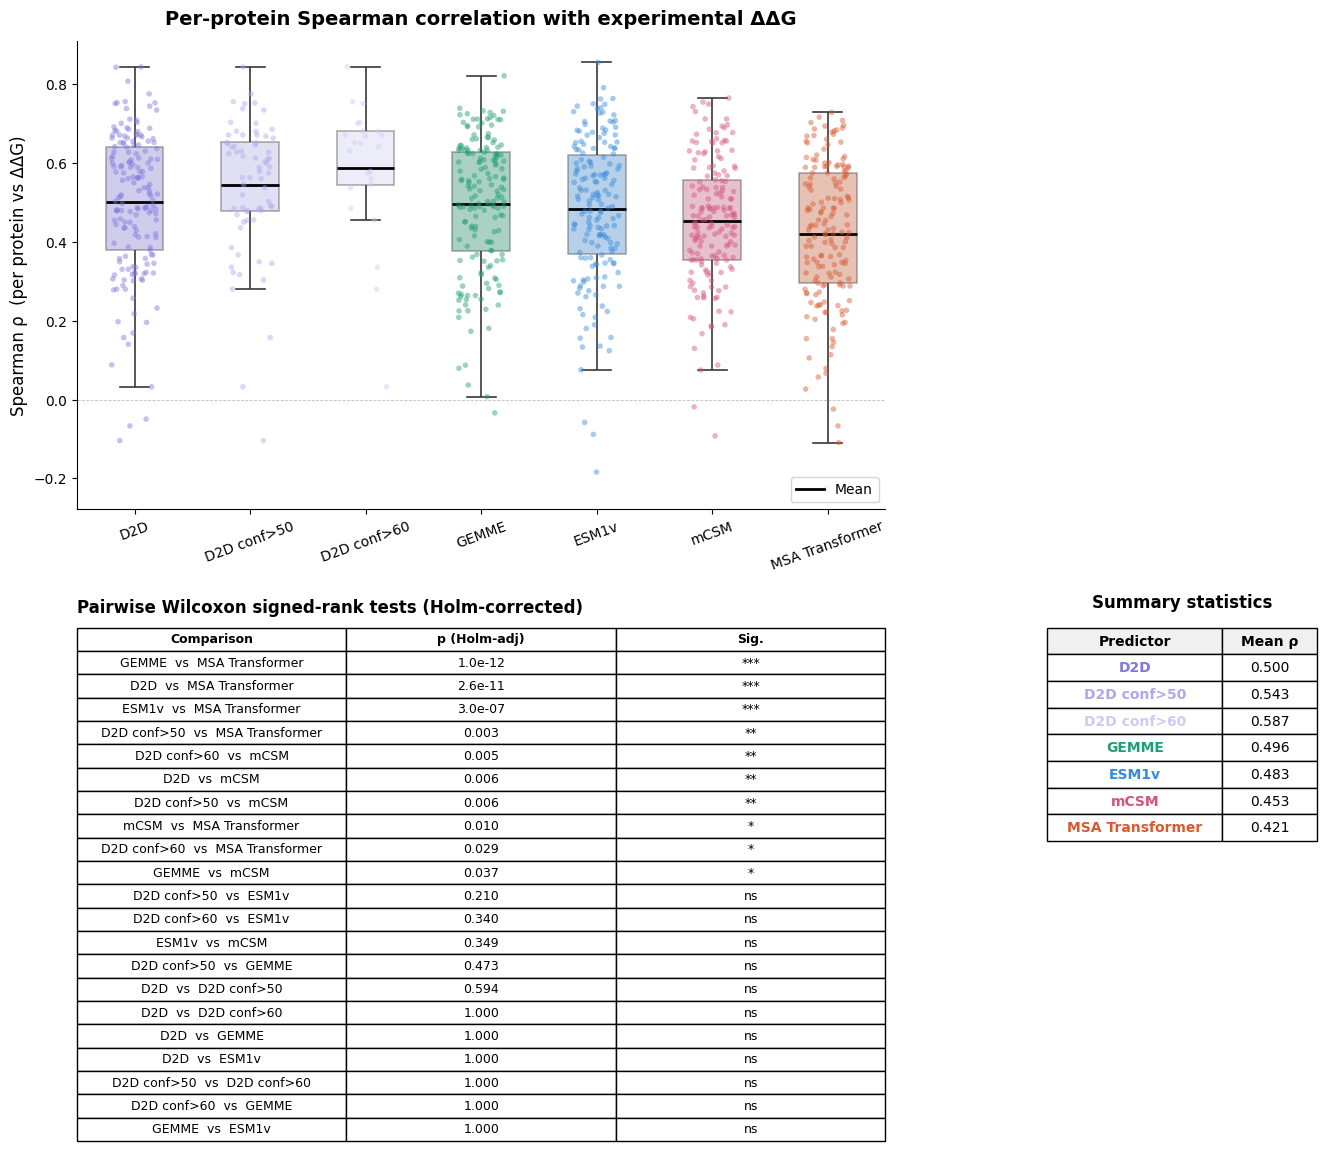

In [ ]:
plot_spearman_comparison(
    metrics,
    save_path='/content/drive/MyDrive/D2D_paper/spearman_comparison_all.png',
)

## 7. Supervised per-protein D2D vs ProtT5 vs PoPMusic
Train a small MLP on D2D and ProtT5 features per protein, compare with PoPMusic.

In [ ]:
!pip install -q transformers sentencepiece
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from transformers import T5EncoderModel, AutoTokenizer
import gc

tokenizer = AutoTokenizer.from_pretrained('Rostlab/prot_t5_xl_uniref50', do_lower_case=False)
prot_model = T5EncoderModel.from_pretrained('Rostlab/prot_t5_xl_uniref50')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prot_model = prot_model.to(device).eval()
gc.collect()

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: Rostlab/prot_t5_xl_uniref50
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


332

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.LeakyReLU(0.01)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)


def train_and_eval(X_train, X_test, y_train, y_test,
                   nb_folds=5, epochs=10, patience=10): # 30 epochs for max performance"
    """Train MLP with K-fold CV, return Spearman on test set."""
    scaler_sv = MinMaxScaler()
    X_train_sc = scaler_sv.fit_transform(X_train)
    X_test_sc = scaler_sv.transform(X_test)

    kf = KFold(n_splits=nb_folds, shuffle=True, random_state=42)
    fold_preds = []

    for train_idx, val_idx in kf.split(X_train_sc):
        Xtr = torch.tensor(X_train_sc[train_idx], dtype=torch.float32)
        ytr = torch.tensor(y_train[train_idx], dtype=torch.float32).view(-1, 1)
        Xval = torch.tensor(X_train_sc[val_idx], dtype=torch.float32)

        train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)

        model_sv = MLP(Xtr.shape[1]).to(device)
        model_sv.apply(init_weights)
        optimizer = optim.Adam(model_sv.parameters(), lr=0.01)
        loss_fn = nn.MSELoss()

        best_loss, best_state, pat_count = np.inf, None, 0

        for epoch in range(epochs):
            model_sv.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss_fn(model_sv(xb), yb).backward()
                optimizer.step()

            model_sv.eval()
            with torch.no_grad():
                val_loss = loss_fn(
                    model_sv(Xval.to(device)),
                    torch.tensor(y_train[val_idx], dtype=torch.float32).view(-1, 1).to(device)
                ).item()

            if val_loss < best_loss:
                best_loss, best_state, pat_count = val_loss, model_sv.state_dict(), 0
            else:
                pat_count += 1
            if pat_count >= patience:
                break

        model_sv.load_state_dict(best_state)
        model_sv.eval()
        with torch.no_grad():
            preds = model_sv(torch.tensor(X_test_sc, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        fold_preds.append(preds)

    mean_preds = np.mean(fold_preds, axis=0)
    return spearmanr(mean_preds, y_test).correlation

In [ ]:
# ── Supervised comparison ──
popmusic_path = '/content/drive/MyDrive/Colab Notebooks/5thYear/mega_scale_popmusic/'
protT5_path = '/content/drive/MyDrive/Colab Notebooks/5thYear/ProtT5_representations/'
d2d_feat_path = D2D_features_dir + '/'

d2d_spearman, prott5_spearman, popmusic_spearman = [], [], []

for file in tqdm(os.listdir(popmusic_path), desc='Supervised comparison'):
    if not file.endswith('.csv'):
        continue
    pdb_id = file.replace('.csv', '')

    try:
        mutations = pd.read_csv(f'{mega_scale_path}all_input_files_new/{pdb_id}.csv')
        d2d = pd.read_csv(os.path.join(d2d_feat_path, f'D2D_features_{pdb_id}.csv'))
    except FileNotFoundError:
        continue

    d2d['features'] = d2d['features'].apply(
        lambda x: [float(i) for i in x.strip('[]').split(',')]
    )
    d2d['ddG'] = parse_ddg_column(mutations['ddG_ML'])
    d2d['mutant'] = mutations['mutant'].tolist()

    d2d.dropna(subset=['ddG'], inplace=True)
    d2d = filter_synonymous(d2d)

    if len(d2d) < 10:
        continue

    X_d2d = np.array(d2d['features'].tolist())
    y = d2d['ddG'].values

    # ProtT5 embeddings
    Xs = []
    filtered_mutations = mutations.loc[d2d.index]
    for _, mut in filtered_mutations.iterrows():
        mut_seq = [' '.join(mut['mut_sequence'])]
        mut_seq = [re.sub(r'[-.UZOB]', 'X', s) for s in mut_seq]
        ids = tokenizer(mut_seq, add_special_tokens=True, padding=True, return_tensors='pt')
        input_ids = ids['input_ids'].to(device)
        attention_mask = ids['attention_mask'].to(device)
        with torch.no_grad():
            emb = prot_model(input_ids=input_ids, attention_mask=attention_mask)
        seq_len = (attention_mask[0] == 1).sum()
        seq_emd = emb.last_hidden_state[0, :seq_len-1].cpu().numpy().mean(axis=1)
        Xs.append(seq_emd)
    gc.collect()
    X_protT5 = np.array(Xs)

    try:
        popmusic = pd.read_csv(f'{popmusic_path}{pdb_id}.csv')
        pop_preds = popmusic['PoPMusic'].values
    except Exception:
        pop_preds = None

    X_train_d2d, X_test_d2d, y_train, y_test, idx_train, idx_test = train_test_split(
        X_d2d, y, list(range(len(X_d2d))), test_size=0.2, random_state=42
    )
    X_train_protT5 = X_protT5[idx_train]
    X_test_protT5 = X_protT5[idx_test]

    sp_d2d = train_and_eval(X_train_d2d, X_test_d2d, y_train, y_test)
    sp_protT5 = train_and_eval(X_train_protT5, X_test_protT5, y_train, y_test)
    sp_pop = spearmanr(pop_preds[idx_test], y_test).correlation if pop_preds is not None else None

    d2d_spearman.append(sp_d2d)
    prott5_spearman.append(sp_protT5)
    if sp_pop is not None:
        popmusic_spearman.append(sp_pop)

    print(f'{pdb_id}: D2D={sp_d2d:.4f}, ProtT5={sp_protT5:.4f}' +
          (f', PoPMusic={sp_pop:.4f}' if sp_pop else ''))

results_pop = [-x for x in popmusic_spearman]
#print(f'\nMeans — D2D: {Average(d2d_spearman):.4f}, ProtT5: {Average(prott5_spearman):.4f}, PoPMusic: {Average(results_pop):.4f}')

Supervised comparison:   0%|          | 0/156 [00:00<?, ?it/s]

1A32: D2D=0.7541, ProtT5=0.6127, PoPMusic=-0.6234
2KZJ: D2D=0.4301, ProtT5=0.2917, PoPMusic=-0.3823
2M9I: D2D=0.5463, ProtT5=0.2399, PoPMusic=-0.5668
1URF: D2D=0.6962, ProtT5=0.2486, PoPMusic=-0.6792
2RRU: D2D=0.7299, ProtT5=0.5154, PoPMusic=-0.7048
1JIC: D2D=0.5941, ProtT5=0.2160, PoPMusic=-0.5030
6FVC: D2D=0.5335, ProtT5=0.1394, PoPMusic=-0.5343
2LYQ: D2D=0.7761, ProtT5=0.4356, PoPMusic=-0.6512
2WNM: D2D=0.6768, ProtT5=0.6364, PoPMusic=-0.5487
2L2D: D2D=0.6755, ProtT5=0.1836, PoPMusic=-0.6877
2LHC: D2D=0.5957, ProtT5=0.0549, PoPMusic=-0.2215
5LXJ: D2D=0.6203, ProtT5=0.3602, PoPMusic=-0.6140
1QKX: D2D=0.7893, ProtT5=0.3209, PoPMusic=-0.6904
5OAO: D2D=0.7162, ProtT5=0.2677, PoPMusic=-0.6268
2LUM: D2D=0.7610, ProtT5=0.3544, PoPMusic=-0.7741
2M9E: D2D=0.7784, ProtT5=0.0712, PoPMusic=-0.7692
1I6C: D2D=0.8159, ProtT5=0.3958, PoPMusic=-0.6717
1WR4: D2D=0.6099, ProtT5=0.3209, PoPMusic=-0.3468
6EWT: D2D=0.7843, ProtT5=0.3156, PoPMusic=-0.7818
2M9F: D2D=0.7989, ProtT5=0.3985, PoPMusic=-0.5958


In [ ]:
print(f'\nMeans — D2D: {Average(d2d_spearman):.4f}, ProtT5: {Average(prott5_spearman):.4f}, PoPMusic: {Average(results_pop):.4f}')


Means — D2D: 0.7420, ProtT5: 0.4193, PoPMusic: 0.5761


In [ ]:
def plot_spearman_comparison(metrics, supervised=None, save_path=None):
    """
    Publication-quality figure comparing per-protein Spearman correlations.
    Includes D2D confidence thresholds and optional supervised predictors.
    D2D variants shown first, then unsupervised sorted by mean, then supervised.
    """

    # ── Unsupervised predictors ──────────────────────────
    predictor_keys = {
        'D2D':             'D2D_spearman',
        'D2D conf>50':     'D2D_conf50_spearman',
        'D2D conf>60':     'D2D_conf60_spearman',
        'GEMME':           'GEMME_spearman',
        'ESM1v':           'ESM_spearman',
        'MSA Transformer': 'MSA_spearman',
        'mCSM':            'mCSM_spearman',
    }

    data_dict = {}
    for label, key in predictor_keys.items():
        vals = metrics.get(key, [])
        if vals:
            data_dict[label] = vals

    # ── Add supervised predictors if provided ────────────
    if supervised:
        for label, vals in supervised.items():
            if vals:
                data_dict[label] = vals

    if not data_dict:
        print('No data to plot.')
        return

    records = []
    for label, vals in data_dict.items():
        for v in vals:
            records.append({'Predictor': label, 'Spearman ρ': v})
    df = pd.DataFrame(records)

    # Order: D2D variants first, then unsupervised by mean, then supervised
    d2d_order = [n for n in ['D2D', 'D2D conf>50', 'D2D conf>60'] if n in data_dict]
    unsupervised_names = [n for n in data_dict
                         if n not in d2d_order
                         and n not in (supervised or {})]
    unsup_sorted = sorted(unsupervised_names,
                          key=lambda n: np.mean(data_dict[n]), reverse=True)
    sup_names = list((supervised or {}).keys())
    sup_sorted = sorted([n for n in sup_names if n in data_dict],
                        key=lambda n: np.mean(data_dict[n]), reverse=True)
    order = d2d_order + unsup_sorted + sup_sorted

    # ── Colour palette ───────────────────────────────────
    palette = {
        'D2D':              '#7F77DD',
        'D2D conf>50':      '#AFA9EC',
        'D2D conf>60':      '#CECBF6',
        'GEMME':            '#1D9E75',
        'ESM1v':            '#378ADD',
        'MSA Transformer':  '#D85A30',
        'mCSM':             '#D4537E',
        'D2D (supervised)': '#534AB7',
        'ProtT5 (supervised)': '#0F6E56',
        'PoPMusic':         '#BA7517',
    }

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[3, 1],
        height_ratios=[3, 1.2],
        hspace=0.35,
        wspace=0.3,
    )

    # ── Panel A: Box + strip plot (mean line) ────────────
    ax_main = fig.add_subplot(gs[0, 0])

    sns.boxplot(
        data=df, x='Predictor', y='Spearman ρ',
        order=order,
        palette=palette,
        width=0.5,
        linewidth=1.2,
        fliersize=0,
        boxprops=dict(alpha=0.4),
        medianprops=dict(linewidth=0, color='none'),
        showmeans=True,
        meanline=True,
        meanprops=dict(color='black', linewidth=2, linestyle='-'),
        ax=ax_main,
    )
    sns.stripplot(
        data=df, x='Predictor', y='Spearman ρ',
        order=order,
        palette=palette,
        size=4,
        alpha=0.45,
        jitter=0.2,
        ax=ax_main,
    )

    # Vertical separator between unsupervised and supervised
    if sup_sorted:
        sep_x = len(d2d_order) + len(unsup_sorted) - 0.5
        ax_main.axvline(sep_x, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)

    ax_main.set_xlabel('')
    ax_main.set_ylabel('Spearman ρ  (per protein vs ΔΔG)', fontsize=12)
    ax_main.set_title(
        'Per-protein Spearman correlation with experimental ΔΔG',
        fontsize=14, fontweight='bold', pad=12,
    )
    ax_main.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax_main.tick_params(axis='x', labelsize=9, rotation=25)
    ax_main.tick_params(axis='y', labelsize=10)

    mean_line = plt.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Mean')
    ax_main.legend(handles=[mean_line], loc='lower right', fontsize=10, framealpha=0.8)
    sns.despine(ax=ax_main)

    # ── Panel B: Summary (predictor + mean) ──────────────
    ax_table = fig.add_subplot(gs[0, 1])
    ax_table.axis('off')

    summary_rows = []
    for name in order:
        vals = data_dict[name]
        summary_rows.append([name, f'{np.mean(vals):.3f}'])

    table = ax_table.table(
        cellText=summary_rows,
        colLabels=['Predictor', 'Mean ρ'],
        cellLoc='center',
        loc='upper center',
        colWidths=[0.65, 0.35],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.5)

    for j in range(2):
        table[0, j].set_text_props(fontweight='bold')
        table[0, j].set_facecolor('#f0f0f0')
    for i, name in enumerate(order):
        table[i + 1, 0].set_text_props(
            color=palette.get(name, 'black'), fontweight='bold'
        )

    ax_table.set_title('Summary statistics', fontsize=12, fontweight='bold', pad=12)

    # ── Panel C: Pairwise Wilcoxon tests ─────────────────
    ax_pw = fig.add_subplot(gs[1, :])
    ax_pw.axis('off')

    names = order
    pairs, pvals = [], []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a = data_dict[names[i]]
            b = data_dict[names[j]]
            min_len = min(len(a), len(b))
            if min_len < 10:
                pairs.append((names[i], names[j], np.nan))
                pvals.append(1.0)
                continue
            try:
                _, p = wilcoxon(a[:min_len], b[:min_len])
                pairs.append((names[i], names[j], p))
                pvals.append(p)
            except Exception:
                pairs.append((names[i], names[j], np.nan))
                pvals.append(1.0)

    reject, pvals_corrected, _, _ = multipletests(pvals, method='holm')

    pw_rows = []
    for (n1, n2, _), padj in sorted(
        zip(pairs, pvals_corrected), key=lambda x: x[1]
    ):
        sig = '***' if padj < 0.001 else '**' if padj < 0.01 else '*' if padj < 0.05 else 'ns'
        p_str = f'{padj:.1e}' if padj < 0.001 else f'{padj:.3f}'
        pw_rows.append([f'{n1}  vs  {n2}', p_str, sig])

    pw_table = ax_pw.table(
        cellText=pw_rows,
        colLabels=['Comparison', 'p (Holm-adj)', 'Sig.'],
        cellLoc='center',
        loc='upper center',
    )
    pw_table.auto_set_font_size(False)
    pw_table.set_fontsize(8)
    pw_table.scale(1.0, 1.3)

    for j in range(3):
        pw_table[0, j].set_text_props(fontweight='bold')
        pw_table[0, j].set_facecolor('#f0f0f0')

    for i, (_, padj) in enumerate(zip(pairs, pvals_corrected)):
        if padj < 0.05:
            for j in range(3):
                pw_table[i + 1, j].set_facecolor('#e8f5e9')

    ax_pw.set_title(
        'Pairwise Wilcoxon signed-rank tests (Holm-corrected)',
        fontsize=12, fontweight='bold', pad=8, loc='left',
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f'Figure saved to {save_path}')

    plt.show()

Figure saved to /content/drive/MyDrive/D2D_paper/mega_scale_supervised_all.png


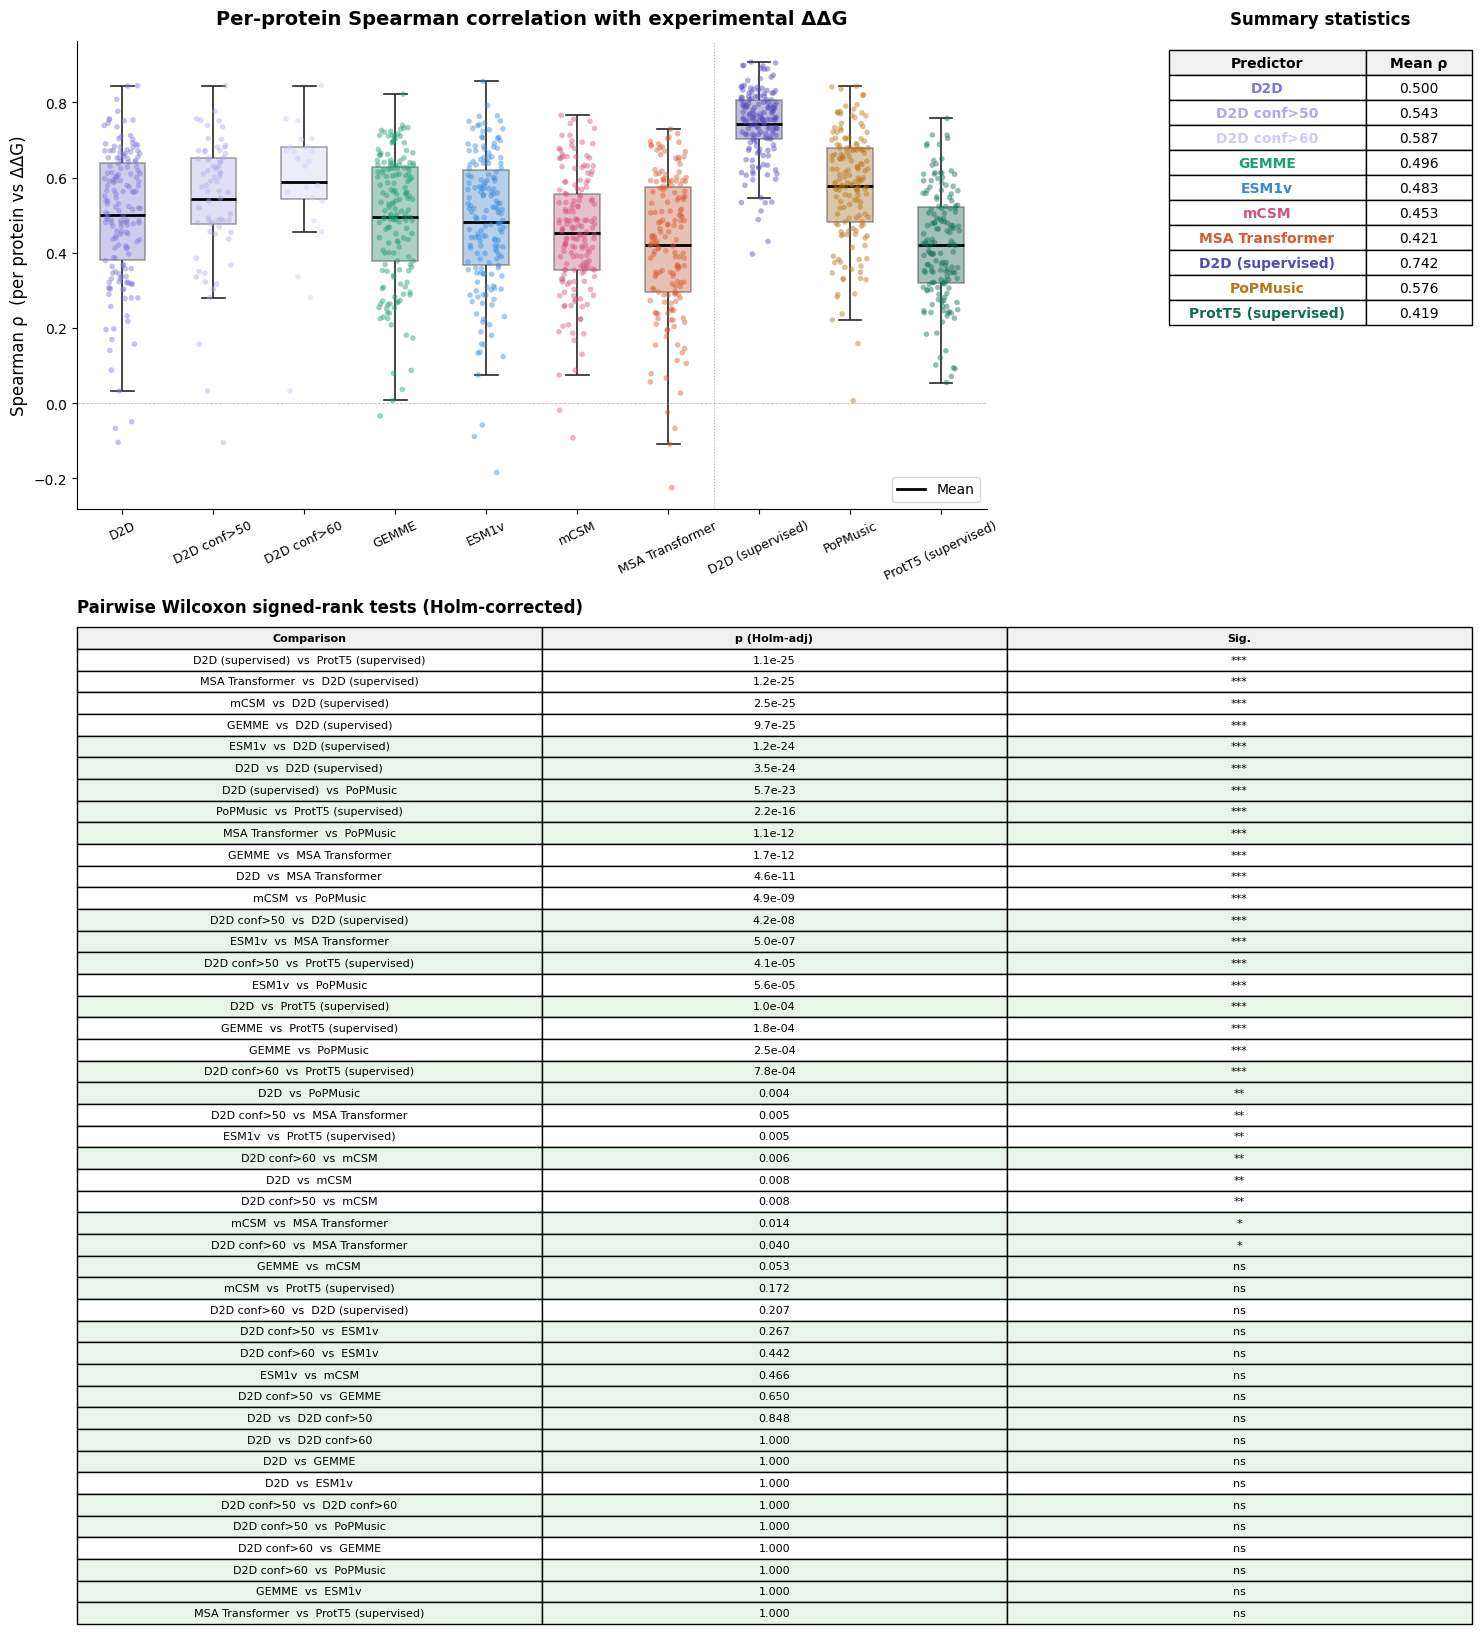

In [ ]:
# ── Combined figure: unsupervised + supervised ────────────
supervised_data = {
    'D2D (supervised)':     d2d_spearman,
    'ProtT5 (supervised)':  prott5_spearman,
    'PoPMusic':             results_pop,
}

plot_spearman_comparison(
    metrics,
    supervised=supervised_data,
    save_path='/content/drive/MyDrive/D2D_paper/mega_scale_supervised_all.png',
)

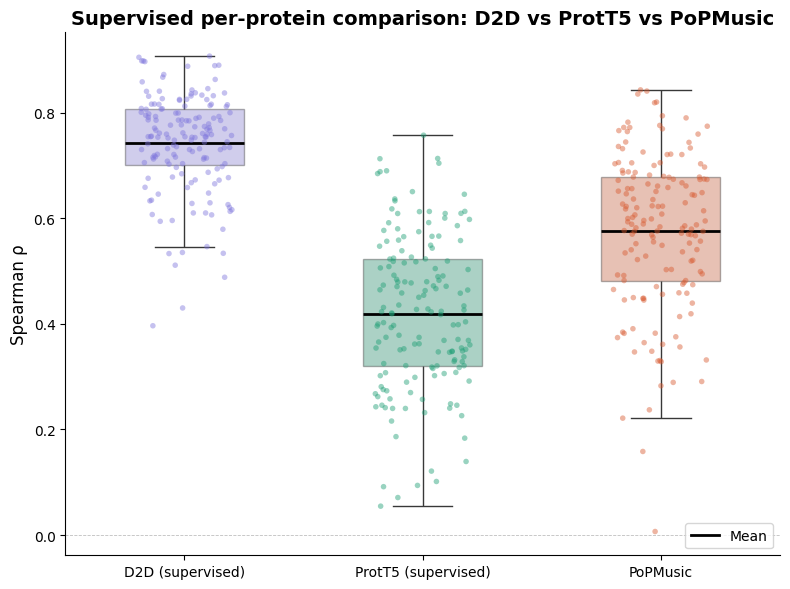

In [ ]:
# ── Supervised comparison plot ────────────────────────────
sup_data = {
    'D2D (supervised)':     d2d_spearman,
    'ProtT5 (supervised)':  prott5_spearman,
    'PoPMusic':             results_pop,
}

sup_records = []
for label, vals in sup_data.items():
    for v in vals:
        sup_records.append({'Predictor': label, 'Spearman ρ': v})
sup_df = pd.DataFrame(sup_records)

sup_palette = {
    'D2D (supervised)':    '#7F77DD',
    'ProtT5 (supervised)': '#1D9E75',
    'PoPMusic':            '#D85A30',
}
sup_order = ['D2D (supervised)', 'ProtT5 (supervised)', 'PoPMusic']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=sup_df, x='Predictor', y='Spearman ρ',
    order=sup_order, palette=sup_palette,
    width=0.5, fliersize=0,
    boxprops=dict(alpha=0.4),
    medianprops=dict(linewidth=0, color='none'),
    showmeans=True, meanline=True,
    meanprops=dict(color='black', linewidth=2, linestyle='-'),
    ax=ax,
)
sns.stripplot(
    data=sup_df, x='Predictor', y='Spearman ρ',
    order=sup_order, palette=sup_palette,
    size=4, alpha=0.45, jitter=0.2, ax=ax,
)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Spearman ρ', fontsize=12)
ax.set_title('Supervised per-protein comparison: D2D vs ProtT5 vs PoPMusic',
             fontsize=14, fontweight='bold')
mean_line = plt.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Mean')
ax.legend(handles=[mean_line], loc='lower right', fontsize=10, framealpha=0.8)
sns.despine()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/D2D_paper/mega_scale_all.png', dpi=600, bbox_inches='tight')
plt.show()

## 8. Epistatic relationships / Compensatory mutations
Analyse whether positions flagged as epistatic by D2D are enriched
for compensatory (stabilising) double mutations.

In [ ]:
overall_epistatic_stable, overall_epistatic_unstable = [], []
overall_nonepistatic_stable, overall_nonepistatic_unstable = [], []


def split_mutations(df, column='mutant'):
    """Split into single-point and double mutations."""
    single = df[~df[column].str.contains(':')].copy()
    multi = df[df[column].str.contains(':')].copy()
    return single, multi


def is_synonymous_single(mutation):
    return mutation[0] == mutation[-1]


def analyze_mutations(pdb_id, threshold=10):
    """Epistasis analysis for one protein."""
    mut_file = f'{mega_scale_path}all_input_files_new/{pdb_id}.csv'
    feat_file = os.path.join(D2D_features_dir, f'D2D_features_{pdb_id}.csv')

    try:
        mutations = pd.read_csv(mut_file)
        d2d = pd.read_csv(feat_file)
    except FileNotFoundError:
        return

    d2d['fl_dif'] = d2d['features'].apply(
        lambda x: [float(v) for v in x.strip('[]').split(',')]
    )
    d2d['GMM_features'] = d2d['fl_dif'].apply(lambda x: sum(x) / len(x))
    d2d['mutant'] = mutations['mutant']
    d2d['ddG'] = pd.to_numeric(mutations['ddG_ML'], errors='coerce')

    if d2d['ddG'].isna().all():
        return

    d2d_single, d2d_multi = split_mutations(d2d)
    d2d_single.dropna(subset=['ddG'], inplace=True)
    d2d_multi.dropna(subset=['ddG'], inplace=True)

    if d2d_multi.empty:
        return

    d2d_multi[['mutation1', 'mutation2']] = d2d_multi['mutant'].str.split(':', expand=True)
    d2d_multi = d2d_multi[
        ~d2d_multi['mutation1'].apply(is_synonymous_single) &
        ~d2d_multi['mutation2'].apply(is_synonymous_single)
    ]

    # Positions involved in multi-mutants
    d2d_multi['pos_first_mut'] = d2d_multi['mutation1'].str[1:-1]
    d2d_multi['pos_sec_mut'] = d2d_multi['mutation2'].str[1:-1]
    d2d_single['pos_mut'] = d2d_single['mutant'].str[1:-1]

    relevant_positions = set(d2d_multi['pos_first_mut']) | set(d2d_multi['pos_sec_mut'])
    singles_at_multi_pos = d2d_single[d2d_single['pos_mut'].isin(relevant_positions)]

    epistatic_stable = epistatic_unstable = 0
    nonepistatic_stable = nonepistatic_unstable = 0

    for _, mut in singles_at_multi_pos.iterrows():
        if mut['ddG'] > 1:
            continue
        max_val = max(mut['fl_dif']) / threshold

        is_first = d2d_multi['mutation1'] == mut['mutant']
        is_second = d2d_multi['mutation2'] == mut['mutant']

        def count_epistasis(df_sub, pos_col):
            nonlocal epistatic_stable, epistatic_unstable
            nonlocal nonepistatic_stable, nonepistatic_unstable
            for pos in df_sub[pos_col].unique():
                temp = df_sub[df_sub[pos_col] == pos]
                val = mut['fl_dif'][int(pos) - 1] if int(pos) - 1 < len(mut['fl_dif']) else 0
                if val > max_val:
                    epistatic_stable += (temp['ddG'] > 1).sum()
                    epistatic_unstable += (temp['ddG'] <= -1).sum()
                else:
                    nonepistatic_stable += (temp['ddG'] > 1).sum()
                    nonepistatic_unstable += (temp['ddG'] <= -1).sum()

        count_epistasis(d2d_multi[is_first], 'pos_sec_mut')
        count_epistasis(d2d_multi[is_second], 'pos_first_mut')

    overall_epistatic_stable.append(epistatic_stable)
    overall_epistatic_unstable.append(epistatic_unstable)
    overall_nonepistatic_stable.append(nonepistatic_stable)
    overall_nonepistatic_unstable.append(nonepistatic_unstable)

In [ ]:
# ── Run epistasis analysis ────────────────────────────────
for file in tqdm(D2D_features_files, desc='Epistasis analysis'):
    pdb_id = file.removeprefix('D2D_features_').removesuffix('.csv')
    if '_' in pdb_id or 'v2' in pdb_id:
        continue
    analyze_mutations(pdb_id, threshold=5)

print(f'Epistatic stable: {sum(overall_epistatic_stable)}')
print(f'Epistatic unstable: {sum(overall_epistatic_unstable)}')
print(f'Non-epistatic stable: {sum(overall_nonepistatic_stable)}')
print(f'Non-epistatic unstable: {sum(overall_nonepistatic_unstable)}')

Epistasis analysis:   0%|          | 0/166 [00:00<?, ?it/s]

Epistatic stable: 868
Epistatic unstable: 283986
Non-epistatic stable: 623
Non-epistatic unstable: 290820


Epistatic     — stable: 868, unstable: 283,986, total: 284,854
Non-epistatic — stable: 623, unstable: 290,820, total: 291,443

Proportion stable — epistatic: 0.0030, non-epistatic: 0.0021

Fisher exact test (one-sided, greater):
  Odds ratio = 1.4268
  p-value    = 5.91e-12

Chi-squared test:
  χ² = 45.83, dof = 1, p = 1.29e-11


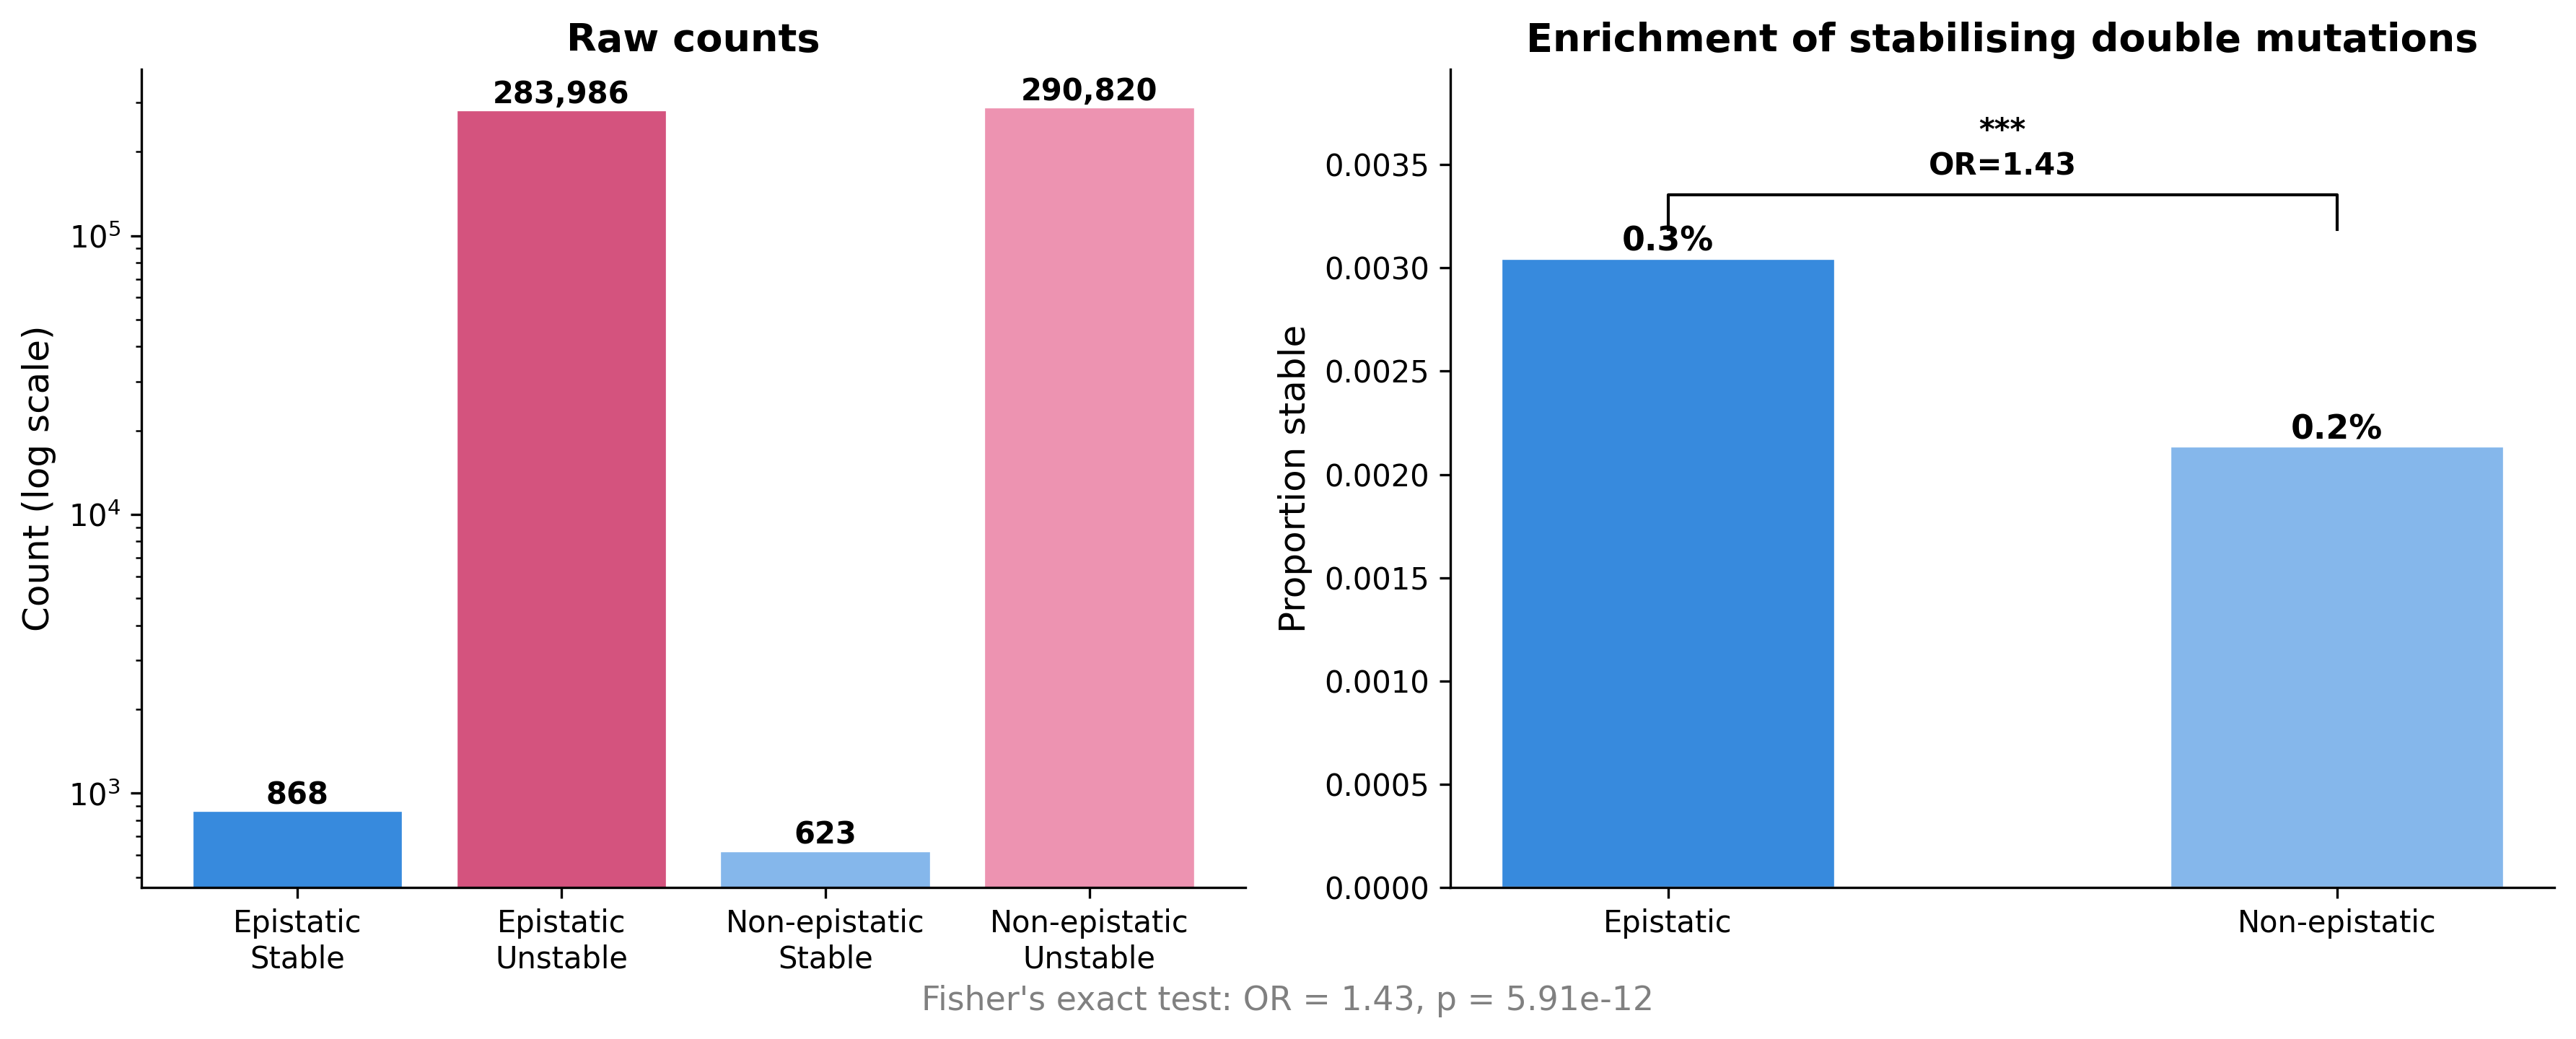

In [ ]:
# ── Epistasis enrichment: statistical test + visualization ─
from scipy.stats import fisher_exact, chi2_contingency

es = sum(overall_epistatic_stable)
eu = sum(overall_epistatic_unstable)
ns = sum(overall_nonepistatic_stable)
nu = sum(overall_nonepistatic_unstable)

print(f'Epistatic     — stable: {es:,}, unstable: {eu:,}, total: {es+eu:,}')
print(f'Non-epistatic — stable: {ns:,}, unstable: {nu:,}, total: {ns+nu:,}')

# Proportions
prop_epi = es / (es + eu) if (es + eu) > 0 else 0
prop_non = ns / (ns + nu) if (ns + nu) > 0 else 0
print(f'\nProportion stable — epistatic: {prop_epi:.4f}, non-epistatic: {prop_non:.4f}')

# ── Fisher's exact test ──────────────────────────────────
contingency = [[es, eu], [ns, nu]]
odds_ratio, p_fisher = fisher_exact(contingency, alternative='greater')
print(f'\nFisher exact test (one-sided, greater):')
print(f'  Odds ratio = {odds_ratio:.4f}')
print(f'  p-value    = {p_fisher:.2e}')

# ── Chi-squared test (for reference with large N) ────────
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print(f'\nChi-squared test:')
print(f'  χ² = {chi2:.2f}, dof = {dof}, p = {p_chi2:.2e}')

# ── Visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Panel A: Raw counts (LOG SCALE)
categories = ['Epistatic\nStable', 'Epistatic\nUnstable',
               'Non-epistatic\nStable', 'Non-epistatic\nUnstable']
counts = [es, eu, ns, nu]
colors = ['#378ADD', '#D4537E', '#85B7EB', '#ED93B1']

bars = axes[0].bar(categories, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_yscale('log')

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].annotate(f'{int(h):,}', (bar.get_x() + bar.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_ylabel('Count (log scale)', fontsize=12)
axes[0].set_title('Raw counts', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=10)
sns.despine(ax=axes[0])

# Panel B: Proportion of stable (the key comparison)
props = [prop_epi, prop_non]
bar_colors = ['#378ADD', '#85B7EB']
bar_labels = ['Epistatic', 'Non-epistatic']
bars2 = axes[1].bar(bar_labels, props, color=bar_colors, edgecolor='white',
                     linewidth=0.8, width=0.5)

for bar in bars2:
    h = bar.get_height()
    axes[1].annotate(f'{h:.1%}', (bar.get_x() + bar.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Proportion stable', fontsize=12)
axes[1].set_ylim(0, max(props) * 1.3 if max(props) > 0 else 1)

# Significance annotation
sig_label = '***' if p_fisher < 0.001 else '**' if p_fisher < 0.01 else '*' if p_fisher < 0.05 else 'ns'
y_bar = max(props) * 1.1 if max(props) > 0 else 0.5
axes[1].plot([0, 0, 1, 1], [y_bar * 0.95, y_bar, y_bar, y_bar * 0.95],
             color='black', linewidth=1)
axes[1].text(0.5, y_bar * 1.02, f'{sig_label}\nOR={odds_ratio:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_title('Enrichment of stabilising double mutations',
                   fontsize=13, fontweight='bold')
sns.despine(ax=axes[1])

plt.suptitle(
    f"Fisher's exact test: OR = {odds_ratio:.2f}, p = {p_fisher:.2e}",
    fontsize=11, color='grey', y=0.02,
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/D2D_paper/Epistatic_sites.png', dpi=600, bbox_inches='tight')
plt.show()

## MSA visualisation

In [ ]:
!pip install -q https://github.com/debbiemarkslab/EVcouplings/archive/develop.zip

     | 18.6 MB 9.7 MB/s 0:00:03
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 36.9 MB/s eta 0:00:00


In [ ]:
import gc
import math
import os
import re
import random
import warnings
from collections import OrderedDict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.mixture import GaussianMixture
from torch.utils.data import Dataset, DataLoader
from transformers import T5EncoderModel, T5Tokenizer
from evcouplings.align import Alignment, read_fasta

pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

In [ ]:
def normalize_minmax(data):
    """Min-max normalize a numpy array."""
    dmin, dmax = np.min(data), np.max(data)
    if dmax == dmin:
        return np.zeros_like(data)
    return (data - dmin) / (dmax - dmin)


def read_a3m(fileobj, inserts="first"):
    """
    Read an alignment in compressed a3m format and expand into a2m format.

    Parameters
    ----------
    fileobj : file-like object
        A3M alignment file.
    inserts : {'first', 'delete'}
        Keep inserts in first sequence, or delete any insert column.

    Returns
    -------
    OrderedDict
        Sequences in alignment (key: ID, value: sequence).
    """
    seqs = OrderedDict()

    for i, (seq_id, seq) in enumerate(read_fasta(fileobj)):
        seq = seq.replace(".", "")

        if inserts == "first":
            if i == 0:
                uppercase_cols = [
                    j for j, c in enumerate(seq)
                    if c == c.upper() or c == "-"
                ]
                gap_template = np.array(["."] * len(seq))
            else:
                uppercase_chars = [
                    c for c in seq if c == c.upper() or c == "-"
                ]
                filled = np.copy(gap_template)
                filled[uppercase_cols] = uppercase_chars
                seq = "".join(filled)

        elif inserts == "delete":
            seq = "".join(c for c in seq if c == c.upper() and c != ".")
        else:
            raise ValueError(f"Invalid option for inserts: {inserts}")

        seqs[seq_id] = seq

    return seqs


def load_and_filter_msa(msa_filepath, min_identity=0.5, max_gap_frac=0.3,
                        fallback_identity=0.2, fallback_gap_frac=0.7,
                        min_sequences=15):
    """Load an MSA from an a3m file and filter by identity and gap fraction.

    If the initial filtering yields fewer than `min_sequences` sequences,
    falls back to more permissive thresholds.

    Parameters
    ----------
    msa_filepath : str
        Path to the .a3m MSA file.
    min_identity : float
        Minimum sequence identity to the first sequence.
    max_gap_frac : float
        Maximum fraction of gap characters per sequence.
    fallback_identity : float
        Relaxed identity threshold if too few sequences remain.
    fallback_gap_frac : float
        Relaxed gap threshold if too few sequences remain.
    min_sequences : int
        Minimum number of sequences before triggering fallback.

    Returns
    -------
    Alignment
        Filtered EVcouplings Alignment object.
    """
    with open(msa_filepath, "r") as infile:
        next(infile)  # skip header
        seqs_dict = read_a3m(infile, inserts="delete")

    aln = Alignment.from_dict(seqs_dict)
    print(f"Raw alignment: {aln.N} sequences, length {aln.L}")

    ident_perc = aln.identities_to(aln.matrix[0])
    gap_fracs = aln.count(axis="seq", char="-")

    def _filter(ident_thresh, gap_thresh):
        return [
            i for i in range(len(ident_perc))
            if ident_perc[i] > ident_thresh and gap_fracs[i] <= gap_thresh
        ]

    keep = _filter(min_identity, max_gap_frac)
    if len(keep) < min_sequences:
        print(f"Only {len(keep)} sequences after strict filter, using relaxed thresholds")
        keep = _filter(fallback_identity, fallback_gap_frac)

    aln_filtered = aln.select(sequences=keep)
    print(f"Filtered alignment: {aln_filtered.N} sequences")
    return aln_filtered

In [ ]:
def plot_msa_depth_distribution(msa_dir, proteins=None, figsize=(12, 5)):
    """Plot a histogram of MSA depths (number of sequences) across proteins.

    Reads all .a3m files in `msa_dir` (or a subset specified by `proteins`),
    loads and filters each MSA, and shows the distribution of filtered depths.

    Parameters
    ----------
    msa_dir : str
        Directory containing .a3m MSA files.
    proteins : list[str] or None
        UniProt accessions to include. If None, all .a3m files in `msa_dir`.
    figsize : tuple
        Figure size.

    Returns
    -------
    pd.DataFrame
        Columns: 'protein', 'raw_depth', 'filtered_depth', 'length'.
    """
    if proteins is None:
        a3m_files = sorted(f for f in os.listdir(msa_dir) if f.endswith('.a3m'))
        proteins = [f.replace('.a3m', '') for f in a3m_files]

    records = []
    for prot in proteins:
        filepath = os.path.join(msa_dir, f"{prot}.a3m")
        if not os.path.isfile(filepath):
            print(f"Skipping {prot}: file not found")
            continue

        with open(filepath, "r") as infile:
            next(infile)
            seqs_dict = read_a3m(infile, inserts="delete")
        aln_raw = Alignment.from_dict(seqs_dict)

        try:
            aln_filt = load_and_filter_msa(filepath)
            filt_depth = aln_filt.N
        except Exception as e:
            print(f"Skipping {prot}: {e}")
            continue

        records.append({
            'protein': prot,
            'raw_depth': aln_raw.N,
            'filtered_depth': filt_depth,
            'length': aln_raw.L,
        })

    if not records:
        print("No MSA files found or processed.")
        return pd.DataFrame()

    df = pd.DataFrame(records)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Raw depth
    axes[0].hist(df['raw_depth'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(df['raw_depth'].median(), color='red', linestyle='--',
                    label=f"median = {df['raw_depth'].median():.0f}")
    axes[0].set_xlabel('Number of sequences')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Raw MSA Depth')
    axes[0].legend()

    # Filtered depth
    axes[1].hist(df['filtered_depth'], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1].axvline(df['filtered_depth'].median(), color='red', linestyle='--',
                    label=f"median = {df['filtered_depth'].median():.0f}")
    axes[1].set_xlabel('Number of sequences')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Filtered MSA Depth')
    axes[1].legend()

    fig.suptitle(f'MSA Depth Distribution (n={len(df)} proteins)', fontsize=14)
    plt.tight_layout()
    plt.show()

    return df

In [ ]:
pdb_ids = []
for pdb_file in D2D_features_files:
  pdb_ids.append(pdb_file.removeprefix('D2D_features_').removesuffix('.csv'))

msa_path= '/content/drive/MyDrive/my_colab/3rdYear/datasets/mmseq2/all_msas/'

Raw alignment: 7901 sequences, length 57
Filtered alignment: 968 sequences
Raw alignment: 2771 sequences, length 72
Filtered alignment: 646 sequences
Raw alignment: 65 sequences, length 70
Filtered alignment: 38 sequences
Raw alignment: 7990 sequences, length 43
Filtered alignment: 1141 sequences
Raw alignment: 6816 sequences, length 37
Filtered alignment: 508 sequences
Raw alignment: 7345 sequences, length 43
Filtered alignment: 198 sequences
Raw alignment: 4498 sequences, length 48
Filtered alignment: 126 sequences
Raw alignment: 69 sequences, length 64
Only 10 sequences after strict filter, using relaxed thresholds
Filtered alignment: 68 sequences
Raw alignment: 7523 sequences, length 61
Filtered alignment: 1071 sequences
Raw alignment: 4873 sequences, length 54
Filtered alignment: 1341 sequences
Raw alignment: 7654 sequences, length 44
Filtered alignment: 281 sequences
Raw alignment: 5801 sequences, length 44
Filtered alignment: 37 sequences
Raw alignment: 7791 sequences, length 48

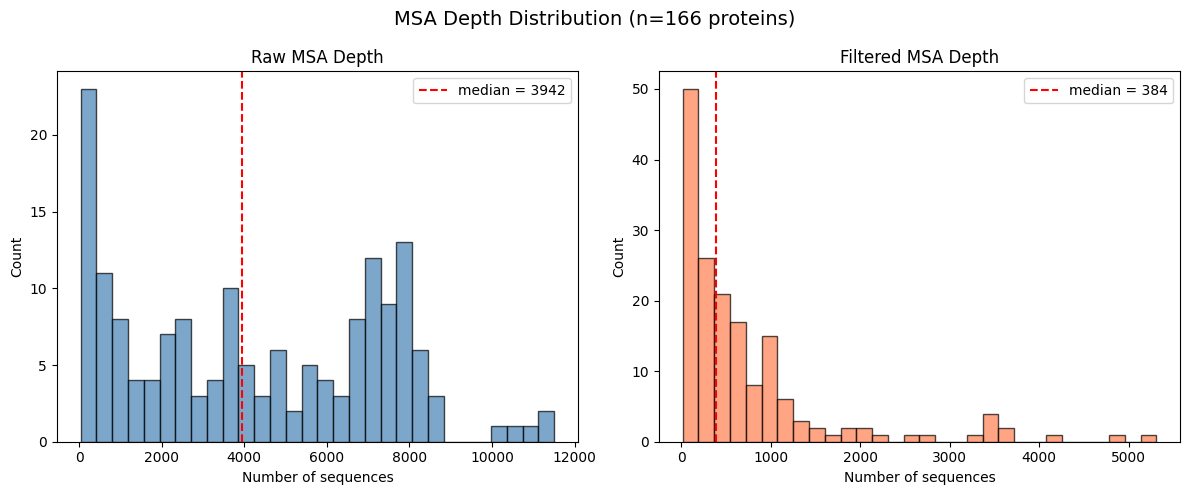

In [ ]:
depth_df = plot_msa_depth_distribution(msa_path, proteins=pdb_ids) # Example: plot_msa_depth_distribution(msa_path) or plot_msa_depth_distribution(msa_path, proteins=['P68431', 'Q96GD4'])

#  Binding-Site Prediction via Linear Interacting Peptides (LIPs)

> **Goal:** Benchmark three binding-site predictors — **D2D**, **ScanNet**, and **P2Rank** — against curated LIP annotations from MobiDB, and evaluate their performance in intrinsically disordered regions (IDR) vs. ordered regions.

---

## 1 · Environment & Imports

In [ ]:
# ── Installation ───────────────────────────────────────────────
# Uncomment the lines below if running for the first time:
# !pip install -q MDAnalysis Biopython scikit_posthocs lightgbm imblearn
# !apt-get install -y dssp

# ── Standard library ──────────────────────────────────────────
import os, re, csv, math, ast, gc, pickle, warnings
from collections import OrderedDict, Counter, defaultdict
from itertools import combinations, product
from urllib.request import urlopen

# ── Scientific stack ──────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (
    spearmanr, kendalltau, shapiro, friedmanchisquare,
    linregress, wilcoxon, mannwhitneyu, normaltest,
    gaussian_kde, fisher_exact, pointbiserialr, kruskal,
    rankdata,
)
from statsmodels.stats.multitest import multipletests

# ── Machine learning ──────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, GridSearchCV,
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef,
    precision_recall_fscore_support, mean_squared_error,
    precision_score, recall_score, f1_score,
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import lightgbm as lgb

# ── Deep learning ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, TensorDataset
from torch.optim import lr_scheduler
from torch.nn.utils.rnn import pad_sequence
from torch.autograd import Variable


# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import matplotlib.patches as patches
import colorsys
import seaborn as sns
import plotly.express as px

# ── Notebook settings ─────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200, "display.max_columns", 50)
sns.set_theme(style="whitegrid", font_scale=1.15, rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

# Colour palette used throughout
PALETTE = {
    "D2D":     "#4C72B0",
    "ScanNet": "#DD8452",
    "P2Rank":  "#55A868",
}

print("✅ All imports loaded.")

✅ All imports loaded.


## 2 · Utility Functions

In [ ]:
# ── Colour helpers ─────────────────────────────────────────────
def adjust_lightness(color, amount: float = 1.0):
    """Shift a colour's lightness by *amount* (>1 lighter, <1 darker)."""
    c = mc.to_rgb(mc.cnames.get(color, color))
    h, l, s = colorsys.rgb_to_hls(*c)
    return colorsys.hls_to_rgb(h, max(0, min(1, l * amount)), s)


# ── Sequence / mutation helpers ───────────────────────────────
def load_uniprot_fasta(identifier: str) -> str:
    """Fetch the canonical FASTA sequence from UniProt."""
    url = f"http://www.uniprot.org/uniprot/{identifier}.fasta"
    raw = requests.get(url).content.decode("utf-8")
    return "".join(raw.split(">")[1].splitlines()[1:])


def extract_characters(value: str):
    """Return (X1, Y1, X2, Y2) from mutation strings like 'T39P' or 'T39P:T46I'."""
    if ":" in value:
        p1, p2 = value.split(":")
        return p1[0], p1[-1], p2[0], p2[-1]
    return value[0], value[-1], None, None


def has_synonymous_mutation(s: str) -> bool:
    return any(o == n for o, n in re.findall(r"([A-Z])\d+([A-Z])", s))


def subtract_from_numbers(s: str, val: int) -> str:
    return re.sub(r"\d+", lambda m: str(int(m.group()) - val), s)


def contains_excluded_numbers(s: str, exclude: list) -> bool:
    return any(int(n) in exclude for n in re.findall(r"\d+", s))


def count_leading_gaps(s: str) -> int:
    return len(s) - len(s.lstrip("-"))


def extract_pdb_id(mutation: str) -> str:
    parts = mutation.split("_")
    return "_".join(parts[:2]) if mutation.count("_") == 2 else parts[0]


# ── Numeric helpers ───────────────────────────────────────────
def safe_mean(lst):
    """Mean of a list, ignoring None / NaN."""
    clean = [x for x in lst if x is not None and not (isinstance(x, float) and math.isnan(x))]
    return np.mean(clean) if clean else np.nan


def all_nan(lst):
    return all(math.isnan(x) for x in lst)


# ── I/O helpers ───────────────────────────────────────────────
def load_csv_files(directory: str) -> list:
    return [pd.read_csv(os.path.join(directory, f))
            for f in sorted(os.listdir(directory)) if f.endswith(".csv")]


def fasta_to_dict(path: str) -> dict:
    d, acc, seq = {}, None, []
    with open(path) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                if acc:
                    d[acc] = "".join(seq)
                acc = line.split("|")[1]
                seq = []
            else:
                seq.append(line)
    if acc:
        d[acc] = "".join(seq)
    return d


print("✅ Utility functions defined.")

✅ Utility functions defined.


## 3 · Evaluation Metrics

In [ ]:
def evaluate_performance(actual: list, predicted: list, total_length: int) -> dict:
    """Compute precision / recall / F1 / accuracy from position lists."""
    actual_s, pred_s = set(actual), set(predicted)
    TP = len(actual_s & pred_s)
    FP = len(pred_s - actual_s)
    FN = len(actual_s - pred_s)
    TN = total_length - TP - FP - FN

    prec = TP / (TP + FP) if (TP + FP) else 0
    rec  = TP / (TP + FN) if (TP + FN) else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    return {"Precision": prec, "Recall": rec, "F1-score": f1, "Accuracy": (TP + TN) / total_length}


def evaluate_region_performance(idr_region, actual_ones, predicted_ones, total_length):
    """Split evaluation into IDR / non-IDR sub-regions."""
    idr_set  = set(idr_region)
    all_pos  = set(range(1, total_length + 1))
    non_idr  = all_pos - idr_set
    act_set  = set(actual_ones)
    pred_set = set(predicted_ones)

    def _metrics(region):
        y_true = [1 if p in act_set  else 0 for p in region]
        y_pred = [1 if p in pred_set else 0 for p in region]
        if sum(y_true) == 0:
            return {"Precision": None, "Recall": None, "F1-score": None}
        return {
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),
            "F1-score":  f1_score(y_true, y_pred, zero_division=0),
        }

    return {"IDR": _metrics(idr_set), "non_IDR": _metrics(non_idr)}


# ── Structural helpers ────────────────────────────────────────
def extract_residue_contacts(pdb_file: str, chain_id: str, cutoff: float = 8.0):
    """Build a residue interaction network (RIN) from a PDB."""
    u = mda.Universe(pdb_file)
    chain = u.select_atoms(f"segid {chain_id} and (protein or resname PTR SEP TPO)")
    G = nx.Graph()
    for r1 in chain.residues:
        for r2 in chain.residues:
            if r1 != r2:
                d = distance_array(r1.atoms.positions, r2.atoms.positions).min()
                if d <= cutoff:
                    G.add_edge(r1.resid, r2.resid)
    return G


def analyze_residue_properties(G, residues):
    """Network centrality metrics for selected residues."""
    bc = nx.betweenness_centrality(G)
    try:
        ec = nx.eigenvector_centrality(G, max_iter=500)
    except nx.NetworkXError:
        ec = defaultdict(float)

    rows = []
    for r in residues:
        if r in G.nodes:
            rows.append({
                "Residue": r,
                "Degree": G.degree(r),
                "Clustering": nx.clustering(G, r),
                "Betweenness": bc.get(r, 0),
                "Eigenvector": ec.get(r, 0),
            })
    return pd.DataFrame(rows)


print("✅ Evaluation functions defined.")

✅ Evaluation functions defined.


## 4 · Region Mapping Helpers

In [ ]:
def _clip_and_shift(regions, pdb_range):
    """Clip annotation regions to PDB range, then shift to 1-based mega-scale coords."""
    filtered = []
    lo, hi = int(pdb_range[0]), int(pdb_range[1])
    for start_s, end_s in regions:
        s, e = int(start_s), int(end_s)
        if e < lo or s > hi:
            continue
        s = max(s, lo)
        e = min(e, hi)
        if s != e:
            filtered.append([s - lo + 1, e - lo + 1])
    return filtered


def flatten_ranges(ranges):
    """Expand [[2, 5], [8, 10]] → [2, 3, 4, 5, 8, 9, 10]."""
    return [p for s, e in ranges for p in range(s, e + 1)]


print("✅ Region mapping helpers defined.")

✅ Region mapping helpers defined.


## 5 · Mega-Scale Pipeline

> Iterates over PDB structures, maps LIP annotations from MobiDB,
> and benchmarks D2D / ScanNet / P2Rank against curated binding sites.

**⚠️  This cell requires access to Google Drive data directories.**
Adjust paths below to match your environment.

In [ ]:
# ── Path configuration ─────────────────────────────────────────
MEGA_SCALE_PATH = "/content/drive/MyDrive/Colab Notebooks/4thYear/mega_scale_stability/"
D2D_UNMUT_PATH  = "/content/drive/MyDrive/Colab Notebooks/5thYear/D2D_features_megascale_revamp/D2D_features_unmutated/"
SCANNET_PATH    = "/content/drive/MyDrive/Colab Notebooks/5thYear/ScanNet/"
P2RANK_PATH     = "/content/drive/MyDrive/Colab Notebooks/5thYear/mega_scale_p2rank/"

# ── Load PDB ↔ UniProt mapping ────────────────────────────────
with open("uniprot_pdb_map.tsv") as fh:
    reader = csv.reader(fh, delimiter="\t")
    uniprot_pdb_map = {row[0]: row[1] for row in reader}

# ── Discover available D2D feature files ──────────────────────
d2d_files = os.listdir(D2D_UNMUT_PATH)
pdb_ids   = [f[len("D2D_features_"):-len(".csv")] for f in d2d_files]

LIP_FEATURES = [
    "curated-lip-merge", "curated-lip-priority,curated-lip-elm",
    "curated-lip-dibs", "curated-lip-disprot", "curated-lip-mfib",
    "curated-lip-ideal",
    "curated-binding_mode_disorder_to_disorder-merge",
    "curated-binding_mode_disorder_to_disorder-priority",
    "curated-binding_mode_disorder_to_disorder-fuzdb",
    "derived-lip-th_90", "derived-lip-priority",
]
IDR_FEATURES = [
    "curated-disorder-merge", "curated-disorder-priority",
    "curated-disorder-uniprot", "curated-disorder-ideal",
    "curated-disorder-disprot",
    "prediction-disorder-priority", "prediction-disorder-th_50",
]

print(f"✅ Found {len(pdb_ids)} structures to process.")

✅ Found 166 structures to process.


In [ ]:
# ── Accumulator dataclass (cleaner than 30+ separate lists) ────
from dataclasses import dataclass, field
from typing import List

@dataclass
class Results:
    # Overall metrics per predictor
    precision: List[float] = field(default_factory=list)
    recall:    List[float] = field(default_factory=list)
    f1:        List[float] = field(default_factory=list)
    accuracy:  List[float] = field(default_factory=list)
    # IDR / non-IDR breakdown
    sens_idr:     List = field(default_factory=list)
    sens_nonidr:  List = field(default_factory=list)
    spec_idr:     List = field(default_factory=list)
    spec_nonidr:  List = field(default_factory=list)
    f1_idr:       List = field(default_factory=list)
    f1_nonidr:    List = field(default_factory=list)

d2d_res     = Results()
scannet_res = Results()
p2rank_res  = Results()

# For global distributions
idr_ddg_all, nonidr_ddg_all = [], []
disordered_aa, lip_aa, lips_in_idr = [], [], []
processed_ids = []

In [ ]:
from Bio import SeqIO, pairwise2
import requests

In [ ]:
# ── Main processing loop ──────────────────────────────────────
for pdb_id in pdb_ids:
    if pdb_id == "2KVS":
        continue

    # ─ Load mutations & D2D features ─
    mut_path = os.path.join(MEGA_SCALE_PATH, "all_input_files_new", f"{pdb_id}.csv")
    if not os.path.exists(mut_path):
        continue
    mutations = pd.read_csv(mut_path)
    if mutations["WT_name"].str.contains("_").any():
        continue

    d2d = pd.read_csv(os.path.join(D2D_UNMUT_PATH, f"D2D_features_{pdb_id}.csv"))
    d2d["fl_dif"]       = d2d["features"].apply(lambda x: [float(i) for i in x[1:-1].split(",")])
    d2d["GMM_features"] = d2d["fl_dif"].apply(lambda x: np.mean(x))
    d2d["ddG"] = [
        float(r["ddG_ML"]) if r["ddG_ML"] != "-" else np.nan
        for _, r in mutations.iterrows()
    ]
    d2d["mutant"] = mutations["mutant"].tolist()

    if all_nan(d2d["ddG"]):
        continue

    # Filter to single, non-synonymous mutations
    d2d = d2d[~d2d["mutant"].str.contains(":")].copy()
    d2d["position"] = d2d["mutant"].str[1:-1].astype(int)
    d2d.dropna(subset=["ddG"], inplace=True)
    d2d[["X1", "Y1", "X2", "Y2"]] = d2d["mutant"].apply(
        lambda x: pd.Series(extract_characters(x))
    )
    d2d = d2d[
        (d2d["X1"] != d2d["Y1"]) & (d2d["X2"].isna() | (d2d["X2"] != d2d["Y2"]))
    ].drop(columns=["X1", "Y1", "X2", "Y2"]).reset_index(drop=True)

    # ─ Identify functional sites (low ΔΔG, high D2D) ─
    q60 = d2d["GMM_features"].quantile(0.6)
    df_lh = d2d[
        (d2d["ddG"] < 1) & (d2d["ddG"] >= -2) & (d2d["GMM_features"] >= q60)
    ]
    func_positions = set(df_lh["position"])

    # ─ Map LIPs from MobiDB ─
    if pdb_id not in uniprot_pdb_map:
        continue
    uniprot_id = uniprot_pdb_map[pdb_id]

    try:
        uniprot_seq = load_uniprot_fasta(uniprot_id)
    except Exception:
        continue

    alignments = pairwise2.align.localms(
        uniprot_seq, mutations.iloc[0]["WT_sequence"], 2, -1, -2, -0.5
    )
    best = max(alignments, key=lambda a: a[2])
    seq2_al, seq1_al, _, start, end = best
    leading = count_leading_gaps(seq2_al)
    pdb_range = [start + 1 - leading, end - leading]

    # Download MobiDB annotations
    lip_tsv = f"{pdb_id}_LIP.tsv"
    if not os.path.exists(lip_tsv):
        r = requests.get(f"https://mobidb.org/api/download?acc={uniprot_id}&format=tsv")
        if r.status_code != 200:
            continue
        with open(lip_tsv, "wb") as fh:
            fh.write(r.content)

    try:
        mobidb = pd.read_csv(lip_tsv, sep="\t", on_bad_lines="skip")
        lips_raw = mobidb[mobidb["feature"].isin(LIP_FEATURES)]["start..end"].values[0].split(",")
        lip_regions = [s.split("..") for s in set(lips_raw)]
    except Exception:
        continue

    lip_positions = flatten_ranges(_clip_and_shift(lip_regions, pdb_range))
    if not lip_positions:
        continue

    # IDR regions
    try:
        idr_raw = mobidb[mobidb["feature"].isin(IDR_FEATURES)]["start..end"].values[0].split(",")
        idr_regions = [s.split("..") for s in set(idr_raw)]
        idr_positions = flatten_ranges(_clip_and_shift(idr_regions, pdb_range))
    except Exception:
        idr_positions = []

    total_len = len(mutations.iloc[0]["WT_sequence"])

    # ─ Accumulate distributions ─
    lips_in_idr.append(len(set(lip_positions) & set(idr_positions)))
    disordered_aa.append(len(idr_positions))
    lip_aa.append(len(lip_positions))
    idr_ddg_all.extend(d2d[d2d["position"].isin(idr_positions)]["ddG"])
    nonidr_ddg_all.extend(d2d[~d2d["position"].isin(idr_positions)]["ddG"])

    # ─ D2D evaluation ─
    m = evaluate_performance(lip_positions, list(func_positions), total_len)
    d2d_res.precision.append(m["Precision"])
    d2d_res.recall.append(m["Recall"])
    d2d_res.f1.append(m["F1-score"])
    d2d_res.accuracy.append(m["Accuracy"])

    mr = evaluate_region_performance(idr_positions, lip_positions, list(func_positions), total_len)
    for attr, key, region in [
        ("sens_idr", "Recall", "IDR"), ("sens_nonidr", "Recall", "non_IDR"),
        ("spec_idr", "Precision", "IDR"), ("spec_nonidr", "Precision", "non_IDR"),
        ("f1_idr", "F1-score", "IDR"), ("f1_nonidr", "F1-score", "non_IDR"),
    ]:
        getattr(d2d_res, attr).append(mr[region][key])

    # ─ ScanNet evaluation ─
    scannet_file = os.path.join(SCANNET_PATH, f"predictions_{pdb_id}.csv")
    if os.path.exists(scannet_file):
        sc = pd.read_csv(scannet_file)
        sc_sites = sc[sc["Binding site probability"] >= 0.5]["Residue Index"].tolist()
        m = evaluate_performance(lip_positions, sc_sites, total_len)
        scannet_res.precision.append(m["Precision"])
        scannet_res.recall.append(m["Recall"])
        scannet_res.f1.append(m["F1-score"])
        scannet_res.accuracy.append(m["Accuracy"])
        mr = evaluate_region_performance(idr_positions, lip_positions, sc_sites, total_len)
        for attr, key, region in [
            ("sens_idr", "Recall", "IDR"), ("sens_nonidr", "Recall", "non_IDR"),
            ("spec_idr", "Precision", "IDR"), ("spec_nonidr", "Precision", "non_IDR"),
            ("f1_idr", "F1-score", "IDR"), ("f1_nonidr", "F1-score", "non_IDR"),
        ]:
            getattr(scannet_res, attr).append(mr[region][key])

    # ─ P2Rank evaluation ─
    p2rank_file = os.path.join(P2RANK_PATH, pdb_id, "structure.pdb_predictions.csv")
    if os.path.exists(p2rank_file):
        p2 = pd.read_csv(p2rank_file)
        results_str = "".join(p2[" residue_ids"].astype(str)).split(" ")
        p2_sites = [int(s.split("A_")[1]) for s in results_str[1:] if "A_" in s]
        m = evaluate_performance(lip_positions, p2_sites, total_len)
        p2rank_res.precision.append(m["Precision"])
        p2rank_res.recall.append(m["Recall"])
        p2rank_res.f1.append(m["F1-score"])
        p2rank_res.accuracy.append(m["Accuracy"])
        mr = evaluate_region_performance(idr_positions, lip_positions, p2_sites, total_len)
        for attr, key, region in [
            ("sens_idr", "Recall", "IDR"), ("sens_nonidr", "Recall", "non_IDR"),
            ("spec_idr", "Precision", "IDR"), ("spec_nonidr", "Precision", "non_IDR"),
            ("f1_idr", "F1-score", "IDR"), ("f1_nonidr", "F1-score", "non_IDR"),
        ]:
            getattr(p2rank_res, attr).append(mr[region][key])

    processed_ids.append(pdb_id)

print(f"\n✅ Processed {len(processed_ids)} structures successfully.")


✅ Processed 38 structures successfully.


## 6 · Aggregate Results

In [ ]:
def _summarise(res, name):
    return pd.DataFrame({
        "Predictor": name,
        "Precision": [safe_mean(res.precision)],
        "Recall":    [safe_mean(res.recall)],
        "F1-score":  [safe_mean(res.f1)],
        "Accuracy":  [safe_mean(res.accuracy)],
    })

summary = pd.concat([
    _summarise(d2d_res, "D2D"),
    _summarise(scannet_res, "ScanNet"),
    _summarise(p2rank_res, "P2Rank"),
], ignore_index=True).set_index("Predictor")

display(summary.style.format("{:.3f}").background_gradient(cmap="YlGn", axis=0))

,Precision,Recall,F1-score,Accuracy
Predictor,,,,
D2D,0.755,0.781,0.735,0.648
ScanNet,0.593,0.130,0.189,0.336
P2Rank,0.637,0.158,0.243,0.353


## 7 · Visualisations

### 7.1 — IDR vs non-IDR: Violin Comparison

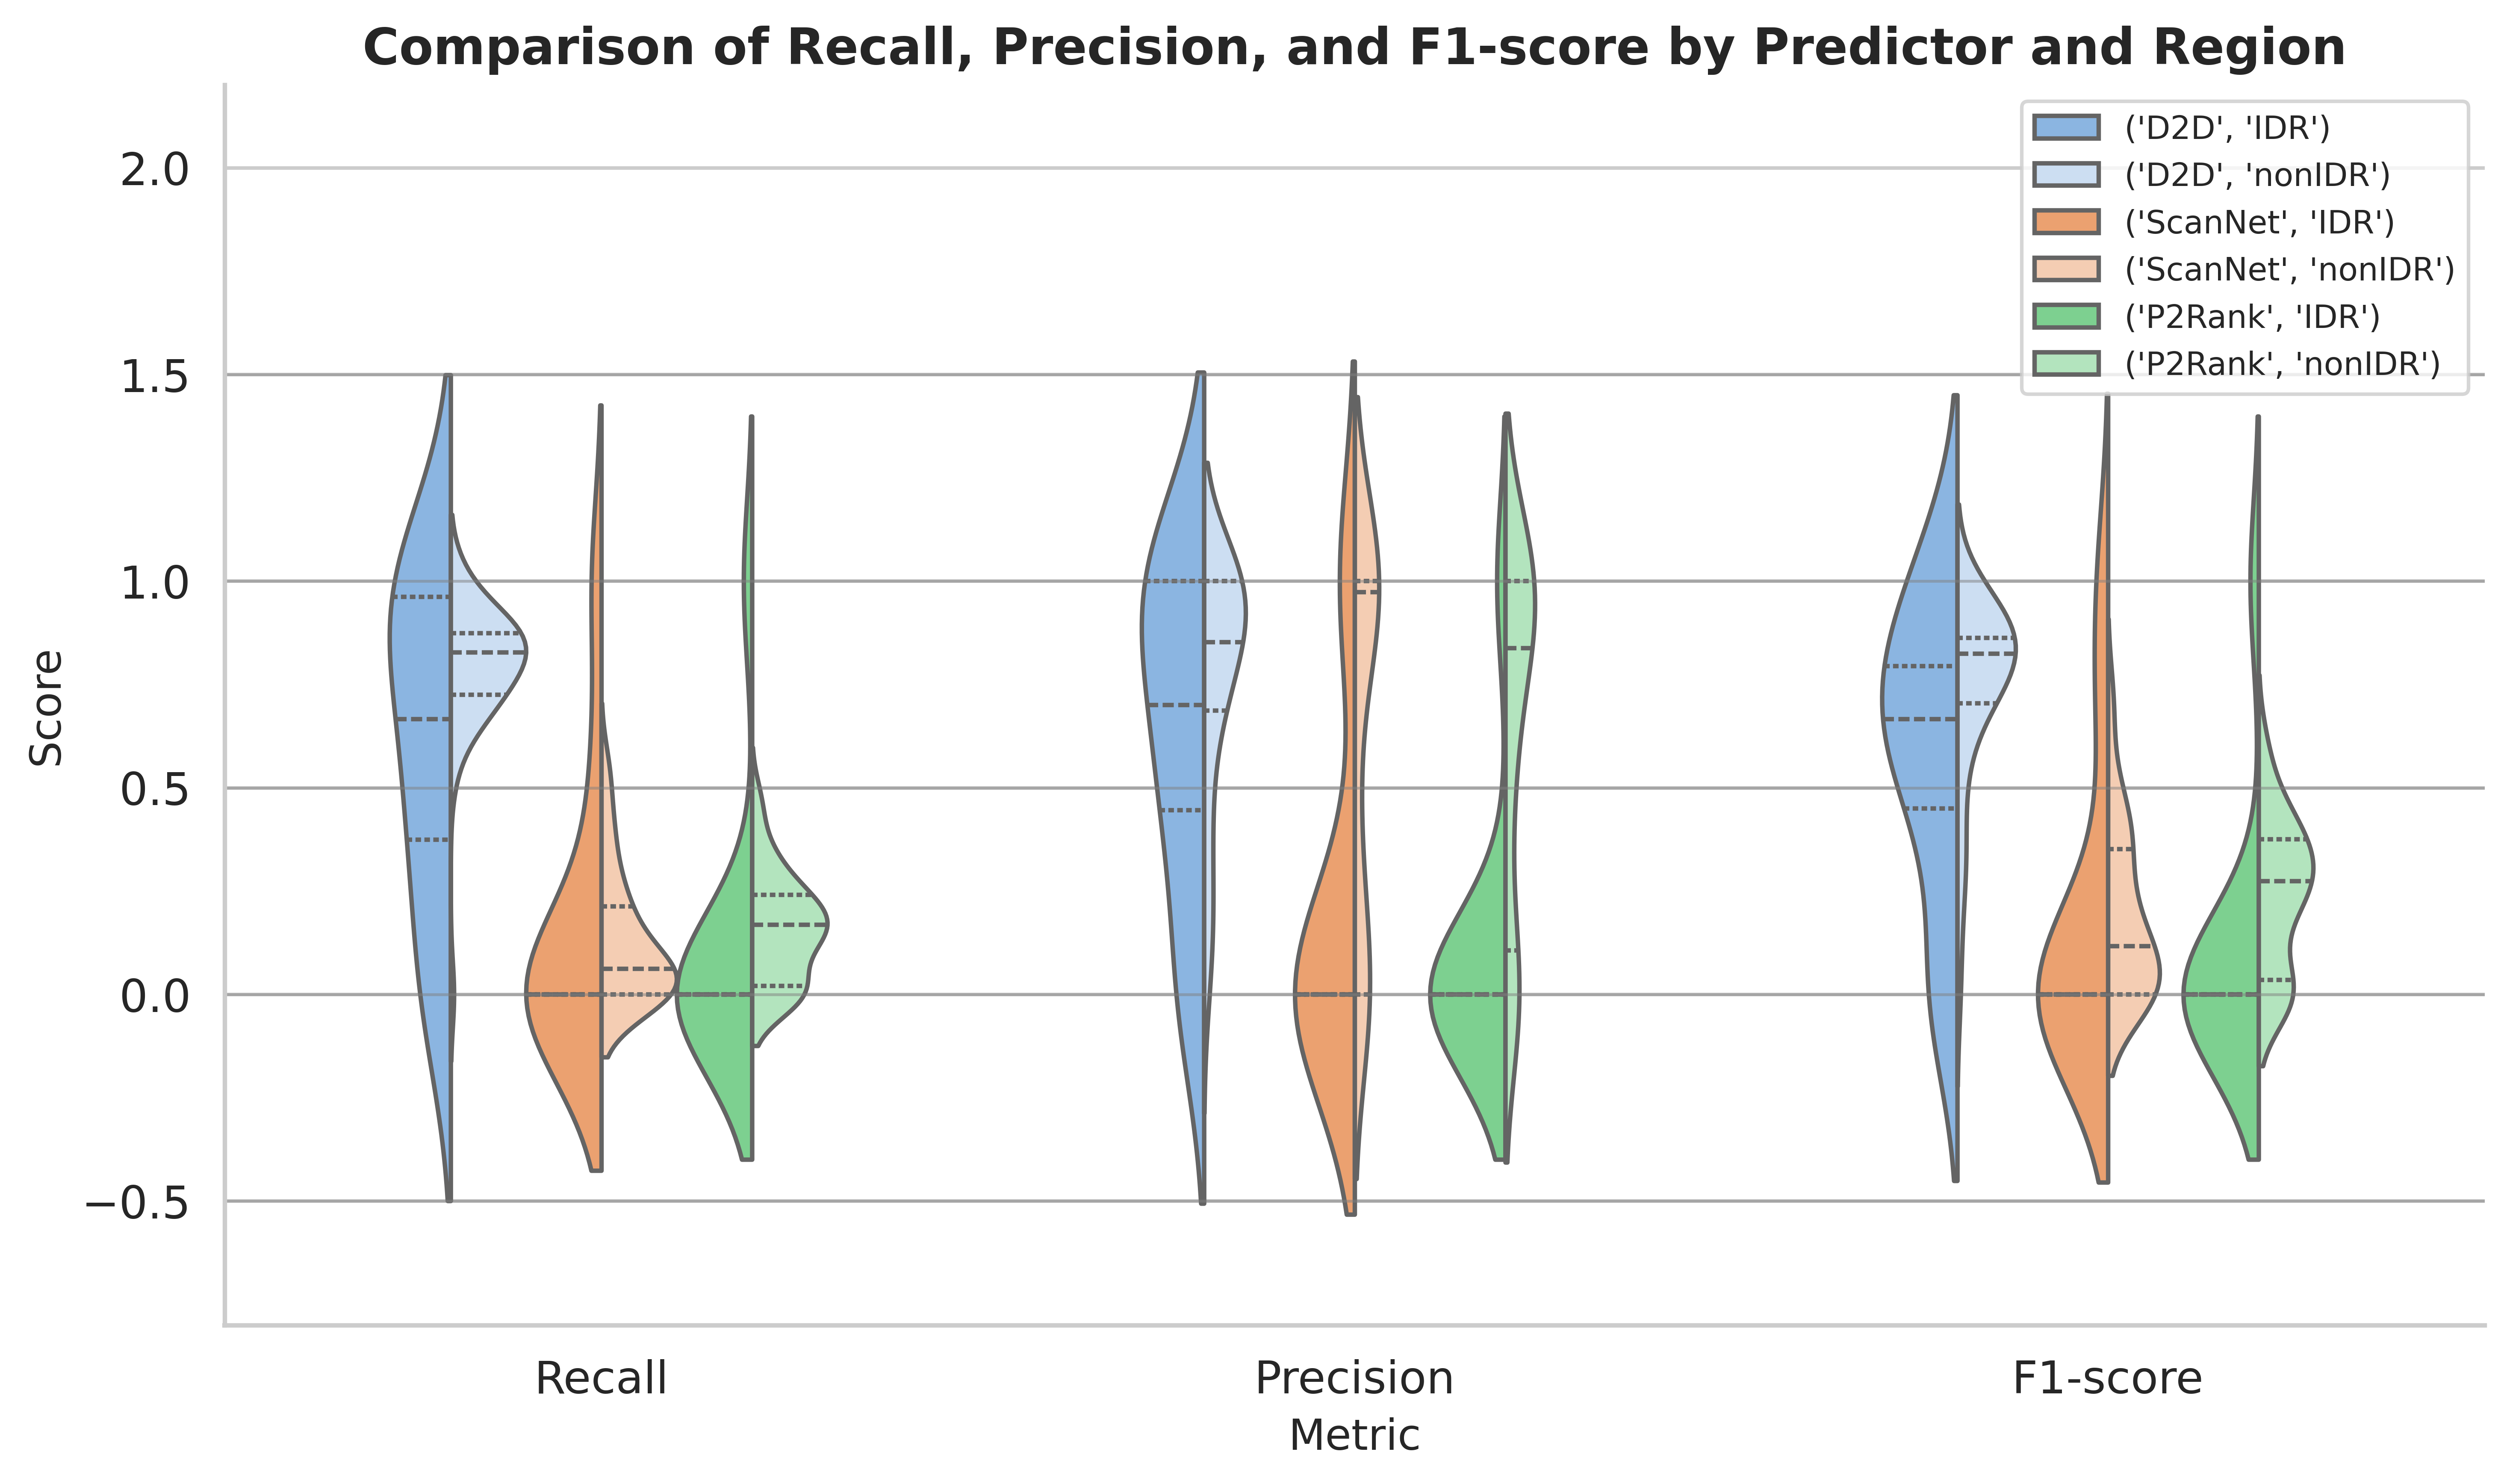

In [ ]:
def _build_df(res, name):
    """Stack IDR / non-IDR metrics into tidy format."""
    rows = []
    for vals, metric in [
        (res.sens_idr, "Recall"), (res.spec_idr, "Precision"), (res.f1_idr, "F1-score"),
    ]:
        for v in vals:
            if v is not None:
                rows.append({"Score": v, "Metric": metric, "Group": "IDR", "predictor": name})
    for vals, metric in [
        (res.sens_nonidr, "Recall"), (res.spec_nonidr, "Precision"), (res.f1_nonidr, "F1-score"),
    ]:
        for v in vals:
            if v is not None:
                rows.append({"Score": v, "Metric": metric, "Group": "nonIDR", "predictor": name})
    return pd.DataFrame(rows)

df_plot = pd.concat([
    _build_df(d2d_res, "D2D"),
    _build_df(scannet_res, "ScanNet"),
    _build_df(p2rank_res, "P2Rank"),
], ignore_index=True)

# ── Pastel palette with IDR (darker) / nonIDR (lighter) per predictor ─
pastel_base = sns.color_palette("pastel")[:3]
predictors = ["D2D", "ScanNet", "P2Rank"]
base_colors = dict(zip(predictors, pastel_base))

custom_palette = {}
for predictor, base in base_colors.items():
    custom_palette[(predictor, "IDR")]    = adjust_lightness(base, 0.9)   # slightly darker
    custom_palette[(predictor, "nonIDR")] = adjust_lightness(base, 1.1)   # slightly lighter

# Composite hue column for (predictor, Group) colouring
df_plot["hue"] = df_plot.apply(lambda row: (row["predictor"], row["Group"]), axis=1)

# ── Combined violin plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), dpi=600)

sns.violinplot(
    x="Metric", y="Score", hue="hue",
    data=df_plot, dodge=True, width=0.6,
    split=True, palette=custom_palette, inner="quart", ax=ax,
)

ax.set_title("Comparison of Recall, Precision, and F1-score by Predictor and Region",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(-0.8, 2.2)
ax.legend(loc="upper right", fontsize=9)

for y in [-0.5, 0, 0.5, 1, 1.5]:
    ax.axhline(y=y, color="gray", alpha=0.5, linewidth=0.8)

fig.tight_layout()
plt.savefig('/content/drive/MyDrive/D2D_paper/violin_idr_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


### 7.2 — Overall Predictor Performance (Bar Chart)

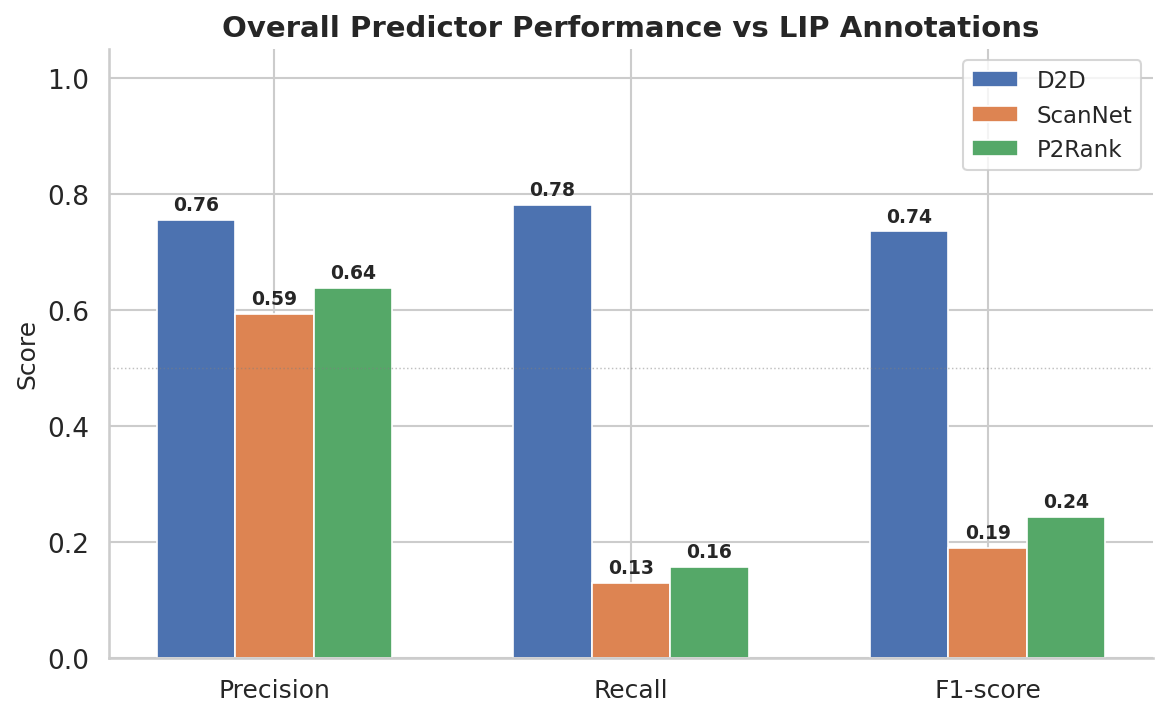

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
width = 0.22
metrics_names = ["Precision", "Recall", "F1-score"]

for i, (name, res) in enumerate([("D2D", d2d_res), ("ScanNet", scannet_res), ("P2Rank", p2rank_res)]):
    vals = [safe_mean(res.precision), safe_mean(res.recall), safe_mean(res.f1)]
    bars = ax.bar(x + i * width, vals, width, label=name, color=PALETTE[name],
                  edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Overall Predictor Performance vs LIP Annotations", fontsize=14, fontweight="bold")
ax.legend(frameon=True, fontsize=11)
ax.axhline(0.5, color="grey", ls=":", lw=0.7, alpha=0.5)

fig.tight_layout()
plt.savefig('/content/drive/MyDrive/D2D_paper/bar_overall_performance.png', dpi=600, bbox_inches='tight')
plt.show()

### 7.3 — ΔΔG Distributions: IDR vs non-IDR

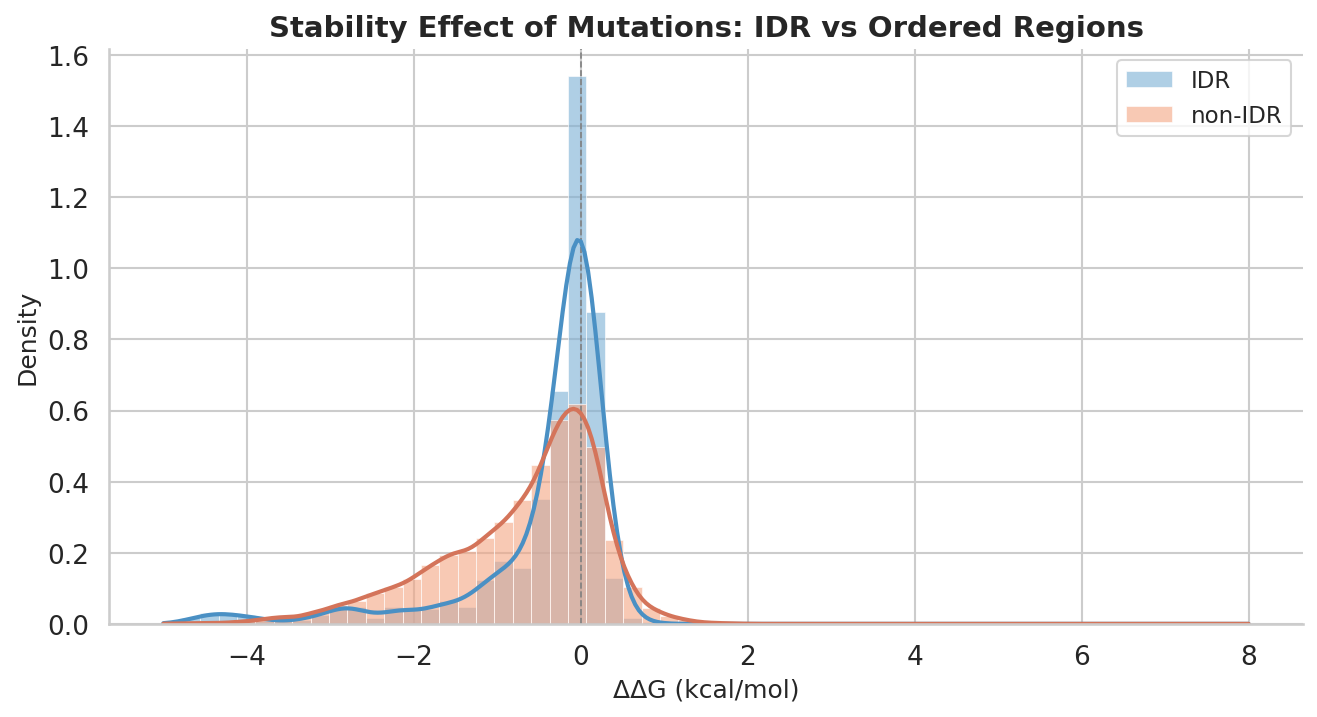

Mann-Whitney U test: U = 36002571, p = 1.55e-58


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(-5, 8, 60)
ax.hist(idr_ddg_all, bins=bins, alpha=0.6, label="IDR", color="#7BAFD4",
        edgecolor="white", linewidth=0.5, density=True)
ax.hist(nonidr_ddg_all, bins=bins, alpha=0.6, label="non-IDR", color="#F4A582",
        edgecolor="white", linewidth=0.5, density=True)

ax.set_xlabel("ΔΔG (kcal/mol)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Stability Effect of Mutations: IDR vs Ordered Regions", fontsize=14, fontweight="bold")
ax.legend(frameon=True, fontsize=11)
ax.axvline(0, color="grey", ls="--", lw=0.8)

# Add KDE overlay
from scipy.stats import gaussian_kde
for data, color in [(idr_ddg_all, "#4A90C4"), (nonidr_ddg_all, "#D4745A")]:
    clean = [x for x in data if not np.isnan(x)]
    if len(clean) > 10:
        kde = gaussian_kde(clean)
        xs = np.linspace(-5, 8, 300)
        ax.plot(xs, kde(xs), color=color, lw=2)

fig.tight_layout()
plt.savefig("ddg_distribution_idr.png", dpi=300, bbox_inches="tight")
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
clean_idr = [x for x in idr_ddg_all if not np.isnan(x)]
clean_non = [x for x in nonidr_ddg_all if not np.isnan(x)]
if clean_idr and clean_non:
    stat, pval = mannwhitneyu(clean_idr, clean_non, alternative="two-sided")
    print(f"Mann-Whitney U test: U = {stat:.0f}, p = {pval:.2e}")

### 7.4 — Radar Chart: Multi-Metric Comparison

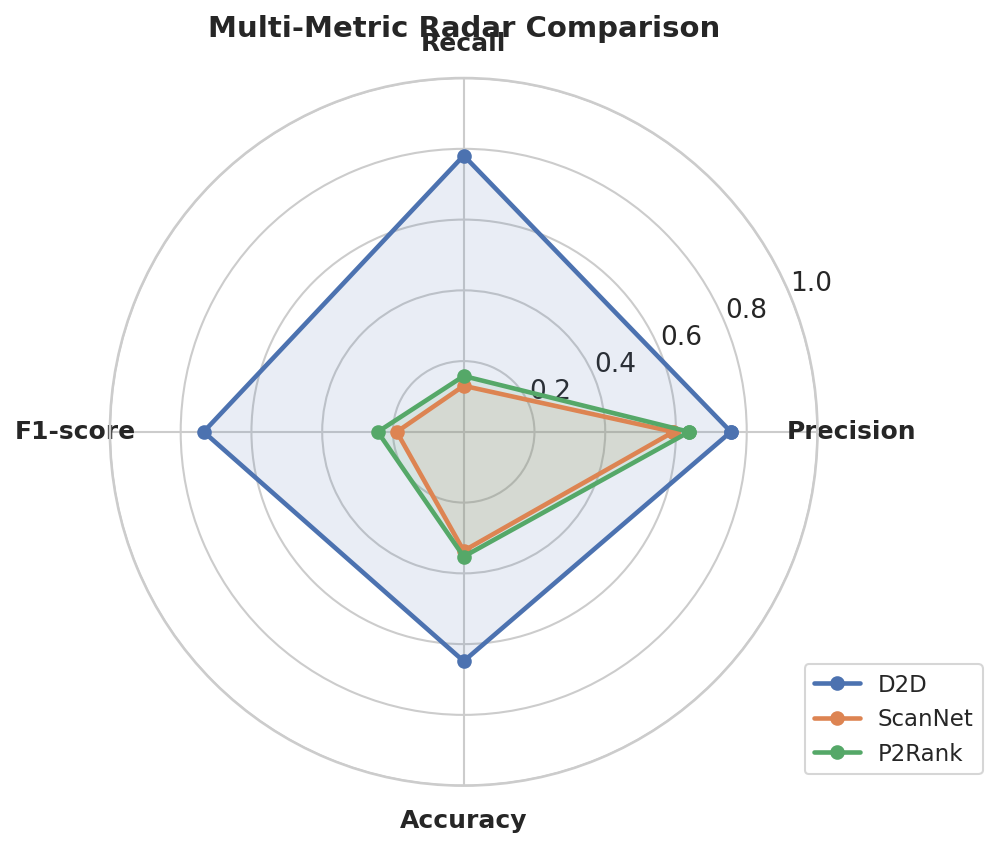

In [ ]:
from matplotlib.patches import FancyBboxPatch

categories = ["Precision", "Recall", "F1-score", "Accuracy"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for name, res, color in [("D2D", d2d_res, PALETTE["D2D"]),
                           ("ScanNet", scannet_res, PALETTE["ScanNet"]),
                           ("P2Rank", p2rank_res, PALETTE["P2Rank"])]:
    vals = [safe_mean(res.precision), safe_mean(res.recall),
            safe_mean(res.f1), safe_mean(res.accuracy)]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2.2, label=name, color=color, markersize=6)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_title("Multi-Metric Radar Comparison", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.25, 0), frameon=True, fontsize=11)

fig.tight_layout()
plt.savefig("radar_comparison.png", dpi=300, bbox_inches="tight")
plt.show()